In [21]:
from google.colab import drive
import os

# Remove any existing files or directories in the mountpoint
if os.path.exists('/content/drive'):
    # Only remove content if it's a directory to avoid issues with other file types
    if os.path.isdir('/content/drive'):
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
            elif os.path.isdir(item_path):
                # Use shutil.rmtree to remove directories
                import shutil
                shutil.rmtree(item_path)

drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


class SpineEnhancementAndAdaptiveROIViewer:
    @staticmethod
    def load_radiograph(path: str):
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"No se pudo leer la radiografía: {path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        return img_rgb, img_gray

    @staticmethod
    def load_binary_mask(path: str, target_shape=None):
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"No se pudo leer la máscara binaria: {path}")

        if target_shape is not None:
            h, w = target_shape[:2]
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        mask = (mask > 0).astype(np.uint8) * 255
        return mask

    @staticmethod
    def normalize(gray: np.ndarray) -> np.ndarray:
        return cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    @staticmethod
    def denoise(gray: np.ndarray) -> np.ndarray:
        return cv2.bilateralFilter(gray, d=7, sigmaColor=30, sigmaSpace=30)

    @staticmethod
    def clahe(gray: np.ndarray, clip_limit=2.5, tile_grid_size=(8, 8)) -> np.ndarray:
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        return clahe.apply(gray)

    @staticmethod
    def unsharp(gray: np.ndarray, sigma=1.2, amount=0.9) -> np.ndarray:
        blurred = cv2.GaussianBlur(gray, (0, 0), sigma)
        sharp = cv2.addWeighted(gray, 1 + amount, blurred, -amount, 0)
        return np.clip(sharp, 0, 255).astype(np.uint8)

    @staticmethod
    def enhance(gray: np.ndarray) -> np.ndarray:
        x = SpineEnhancementAndAdaptiveROIViewer.normalize(gray)
        x = SpineEnhancementAndAdaptiveROIViewer.denoise(x)
        x = SpineEnhancementAndAdaptiveROIViewer.clahe(x, clip_limit=2.5, tile_grid_size=(8, 8))
        x = SpineEnhancementAndAdaptiveROIViewer.unsharp(x, sigma=1.2, amount=0.9)
        return x

    @staticmethod
    def remove_small_components(mask: np.ndarray, min_area: int = 200):
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        cleaned = np.zeros_like(mask)
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area >= min_area:
                cleaned[labels == i] = 255
        return cleaned

    @staticmethod
    def refine_mask(binary_mask: np.ndarray,
                    open_kernel_size: int = 5,
                    close_kernel_size: int = 9,
                    dilate_kernel_size: int = 15,
                    dilate_iterations: int = 1,
                    min_area: int = 200):
        # apertura para ruido fino
        open_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (open_kernel_size, open_kernel_size)
        )
        refined = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, open_kernel)

        # cierre para unir segmentos cercanos
        close_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (close_kernel_size, close_kernel_size)
        )
        refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, close_kernel)

        # quitar componentes pequeñas
        refined = SpineEnhancementAndAdaptiveROIViewer.remove_small_components(refined, min_area=min_area)

        # dilatación ligera
        dilate_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (dilate_kernel_size, dilate_kernel_size)
        )
        refined = cv2.dilate(refined, dilate_kernel, iterations=dilate_iterations)

        return refined

    @staticmethod
    def get_bbox_from_mask(mask: np.ndarray, padding: int = 20):
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            raise ValueError("La máscara refinada está vacía.")

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        h, w = mask.shape[:2]
        x_min = max(0, x_min - padding)
        y_min = max(0, y_min - padding)
        x_max = min(w - 1, x_max + padding)
        y_max = min(h - 1, y_max + padding)

        return x_min, y_min, x_max, y_max

    @staticmethod
    def smooth_1d(arr: np.ndarray, ksize: int = 31):
        if len(arr) < 3:
            return arr.copy()
        if ksize % 2 == 0:
            ksize += 1
        ksize = min(ksize, len(arr) if len(arr) % 2 == 1 else len(arr) - 1)
        if ksize < 3:
            return arr.copy()

        kernel = np.ones(ksize, dtype=np.float32) / ksize
        padded = np.pad(arr, (ksize // 2, ksize // 2), mode="edge")
        smoothed = np.convolve(padded, kernel, mode="valid")
        return smoothed

    @staticmethod
    def compute_centerline_and_width(mask: np.ndarray, smooth_kernel: int = 31):
        """
        Calcula:
        - centerline x(y)
        - half_width(y) basado en ancho observado por fila
        """
        h, w = mask.shape[:2]
        ys_valid = []
        xs_center = []
        widths = []

        for y in range(h):
            xs = np.where(mask[y] > 0)[0]
            if len(xs) > 0:
                ys_valid.append(y)
                xs_center.append(xs.mean())
                widths.append(xs.max() - xs.min() + 1)

        if len(ys_valid) < 2:
            raise ValueError("No hay suficientes filas válidas para construir la centerline.")

        ys_valid = np.array(ys_valid, dtype=np.int32)
        xs_center = np.array(xs_center, dtype=np.float32)
        widths = np.array(widths, dtype=np.float32)

        # Interpolación a todas las filas dentro del rango observado
        y_full = np.arange(ys_valid.min(), ys_valid.max() + 1, dtype=np.int32)
        x_interp = np.interp(y_full, ys_valid, xs_center)
        w_interp = np.interp(y_full, ys_valid, widths)

        # Suavizado
        x_smooth = SpineEnhancementAndAdaptiveROIViewer.smooth_1d(x_interp, ksize=smooth_kernel)
        w_smooth = SpineEnhancementAndAdaptiveROIViewer.smooth_1d(w_interp, ksize=smooth_kernel)

        return y_full, x_smooth, w_smooth

    @staticmethod
    def build_adaptive_band(mask_shape,
                            y_full,
                            x_center,
                            widths,
                            width_scale: float = 0.75,
                            min_half_width: int = 18,
                            max_half_width: int = 60,
                            extra_margin: int = 8):
        h, w = mask_shape[:2]
        band = np.zeros((h, w), dtype=np.uint8)

        for y, xc, row_w in zip(y_full, x_center, widths):
            half_width = int(row_w * width_scale / 2.0) + extra_margin
            half_width = max(min_half_width, half_width)
            half_width = min(max_half_width, half_width)

            x1 = max(0, int(round(xc)) - half_width)
            x2 = min(w - 1, int(round(xc)) + half_width)
            band[y, x1:x2 + 1] = 255

        # Suavizar continuidad vertical de la banda
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        band = cv2.morphologyEx(band, cv2.MORPH_CLOSE, kernel)
        return band

    @staticmethod
    def draw_bbox(gray: np.ndarray, bbox, color=(255, 0, 0), thickness=2):
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(rgb, (x_min, y_min), (x_max, y_max), color, thickness)
        return rgb

    @staticmethod
    def draw_centerline_and_band(gray: np.ndarray, band_mask: np.ndarray, y_full, x_center):
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

        # Overlay de banda en verde
        overlay = rgb.copy()
        overlay[band_mask > 0] = [0, 255, 0]
        rgb = cv2.addWeighted(rgb, 0.75, overlay, 0.25, 0)

        # Centerline en rojo
        for y, xc in zip(y_full, x_center):
            x_int = int(round(xc))
            if 0 <= y < rgb.shape[0] and 0 <= x_int < rgb.shape[1]:
                cv2.circle(rgb, (x_int, int(y)), 1, (255, 0, 0), -1)

        return rgb

    @staticmethod
    def apply_mask(gray: np.ndarray, mask: np.ndarray) -> np.ndarray:
        out = np.zeros_like(gray)
        out[mask > 0] = gray[mask > 0]
        return out

    @staticmethod
    def crop_from_mask(gray: np.ndarray, mask: np.ndarray, padding: int = 10):
        x_min, y_min, x_max, y_max = SpineEnhancementAndAdaptiveROIViewer.get_bbox_from_mask(mask, padding=padding)
        crop = gray[y_min:y_max + 1, x_min:x_max + 1]
        return crop, (x_min, y_min, x_max, y_max)

    @staticmethod
    def process(
        radiograph_path: str,
        binary_mask_path: str,
        open_kernel_size: int = 5,
        close_kernel_size: int = 9,
        dilate_kernel_size: int = 15,
        dilate_iterations: int = 1,
        min_area: int = 200,
        bbox_padding: int = 20,
        centerline_smooth_kernel: int = 31,
        width_scale: float = 0.75,
        min_half_width: int = 18,
        max_half_width: int = 60,
        extra_margin: int = 8,
        show: bool = True
    ):
        original_rgb, original_gray = SpineEnhancementAndAdaptiveROIViewer.load_radiograph(radiograph_path)
        binary_mask = SpineEnhancementAndAdaptiveROIViewer.load_binary_mask(
            binary_mask_path,
            target_shape=original_gray.shape
        )

        enhanced = SpineEnhancementAndAdaptiveROIViewer.enhance(original_gray)

        refined_mask = SpineEnhancementAndAdaptiveROIViewer.refine_mask(
            binary_mask=binary_mask,
            open_kernel_size=open_kernel_size,
            close_kernel_size=close_kernel_size,
            dilate_kernel_size=dilate_kernel_size,
            dilate_iterations=dilate_iterations,
            min_area=min_area
        )

        # ROI rectangular clásica
        bbox = SpineEnhancementAndAdaptiveROIViewer.get_bbox_from_mask(refined_mask, padding=bbox_padding)
        roi_detected_bbox = SpineEnhancementAndAdaptiveROIViewer.draw_bbox(enhanced, bbox)
        x_min, y_min, x_max, y_max = bbox
        roi_rect_crop = enhanced[y_min:y_max + 1, x_min:x_max + 1]
        target_rect_crop = refined_mask[y_min:y_max + 1, x_min:x_max + 1]

        # ROI anatómica adaptativa
        y_full, x_center, widths = SpineEnhancementAndAdaptiveROIViewer.compute_centerline_and_width(
            refined_mask,
            smooth_kernel=centerline_smooth_kernel
        )

        adaptive_band = SpineEnhancementAndAdaptiveROIViewer.build_adaptive_band(
            mask_shape=refined_mask.shape,
            y_full=y_full,
            x_center=x_center,
            widths=widths,
            width_scale=width_scale,
            min_half_width=min_half_width,
            max_half_width=max_half_width,
            extra_margin=extra_margin
        )

        roi_detected_adaptive = SpineEnhancementAndAdaptiveROIViewer.draw_centerline_and_band(
            enhanced,
            adaptive_band,
            y_full,
            x_center
        )

        roi_adaptive_masked = SpineEnhancementAndAdaptiveROIViewer.apply_mask(enhanced, adaptive_band)
        roi_adaptive_crop, adaptive_bbox = SpineEnhancementAndAdaptiveROIViewer.crop_from_mask(
            roi_adaptive_masked,
            adaptive_band,
            padding=10
        )
        target_adaptive_masked = SpineEnhancementAndAdaptiveROIViewer.apply_mask(refined_mask, adaptive_band)
        target_adaptive_crop, _ = SpineEnhancementAndAdaptiveROIViewer.crop_from_mask(
            target_adaptive_masked,
            adaptive_band,
            padding=10
        )

        result = {
            "original": original_gray,
            "enhanced": enhanced,
            "binary_mask": binary_mask,
            "refined_mask": refined_mask,
            "bbox": bbox,
            "roi_detected_bbox": roi_detected_bbox,
            "roi_rect_crop": roi_rect_crop,
            "y_full": y_full,
            "x_center": x_center,
            "widths": widths,
            "adaptive_band": adaptive_band,
            "roi_detected_adaptive": roi_detected_adaptive,
            "roi_adaptive_masked": roi_adaptive_masked,
            "roi_adaptive_crop": roi_adaptive_crop,
            "adaptive_bbox": adaptive_bbox,
            "target_full_mask": refined_mask,
            "target_rect_crop": target_rect_crop,
            "target_adaptive_masked": target_adaptive_masked,
            "target_adaptive_crop": target_adaptive_crop,
        }

        if show:
            fig, axes = plt.subplots(2, 4, figsize=(18, 14))

            axes[0, 0].imshow(result["original"], cmap="gray")
            axes[0, 0].set_title("1. Radiografía original")
            axes[0, 0].axis("off")

            axes[0, 1].imshow(result["enhanced"], cmap="gray")
            axes[0, 1].set_title("2. Quality enhancement")
            axes[0, 1].axis("off")

            axes[0, 2].imshow(result["refined_mask"], cmap="gray")
            axes[0, 2].set_title("3. Máscara refinada")
            axes[0, 2].axis("off")

            axes[0, 3].imshow(result["roi_detected_bbox"])
            axes[0, 3].set_title("4. ROI rectangular")
            axes[0, 3].axis("off")

            axes[1, 0].imshow(result["roi_rect_crop"], cmap="gray")
            axes[1, 0].set_title("5. Crop rectangular")
            axes[1, 0].axis("off")

            axes[1, 1].imshow(result["roi_detected_adaptive"])
            axes[1, 1].set_title("6. Centerline + banda anatómica")
            axes[1, 1].axis("off")

            axes[1, 2].imshow(result["roi_adaptive_masked"], cmap="gray")
            axes[1, 2].set_title("7. ROI anatómica enmascarada")
            axes[1, 2].axis("off")

            axes[1, 3].imshow(result["roi_adaptive_crop"], cmap="gray")
            axes[1, 3].set_title("8. ROI anatómica recortada")
            axes[1, 3].axis("off")

            plt.tight_layout()
            plt.show()

        return result

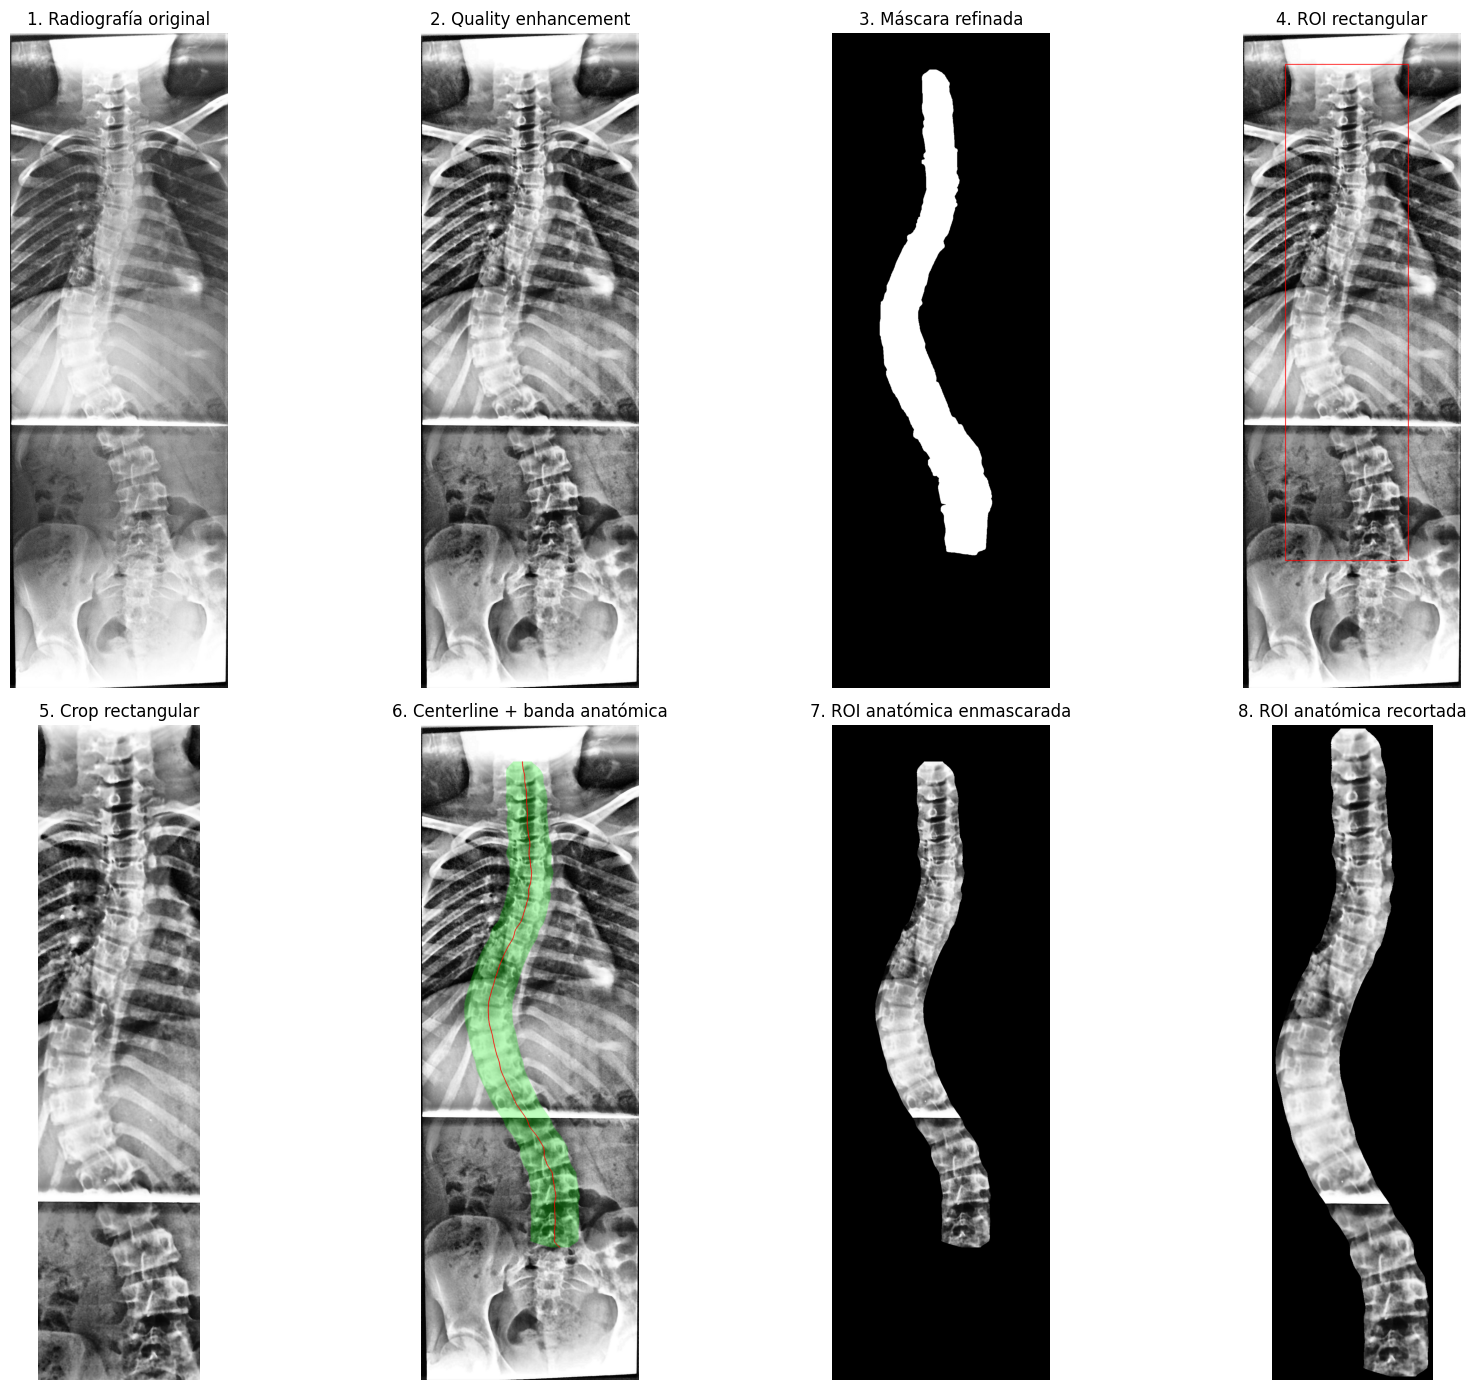

In [23]:
radiograph_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_103.jpg"
binary_mask_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_S_103.jpg"

result = SpineEnhancementAndAdaptiveROIViewer.process(
    radiograph_path=radiograph_path,
    binary_mask_path=binary_mask_path,
    open_kernel_size=5,
    close_kernel_size=9,
    dilate_kernel_size=14,
    min_area=200,
    bbox_padding=20,
    centerline_smooth_kernel=31,
    width_scale=1.10,
    min_half_width=28,
    max_half_width=90,
    extra_margin=14,
    show=True
)

In [24]:
import json
import math
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
from PIL import Image

try:
    from scipy import ndimage as ndi
except ImportError:
    ndi = None


# =========================================================
# DATACLASSES
# =========================================================

@dataclass
class CaseIdentity:
    case_key: str          # ejemplo: S_21 o N_7
    prefix: str            # S o N
    patient_number: int    # 21, 7, etc.
    diagnosis: str         # scoliosis | normal


@dataclass
class ImageCaseRecord:
    case_key: str
    prefix: str
    patient_number: int
    diagnosis: str
    gray_mask_path: Optional[str] = None
    radiograph_path: Optional[str] = None


@dataclass
class GrayBlobInfo:
    class_id: int
    class_name: str
    area: int
    bbox: Tuple[int, int, int, int]   # (ymin, xmin, ymax, xmax)
    centroid: Tuple[float, float]     # (y, x)


@dataclass
class GrayClassSummary:
    class_id: int
    class_name: str
    gray_expected: Optional[int]
    pixel_count: int
    present: bool
    num_components: int = 0
    mean_distance: Optional[float] = None
    weak: bool = False
    ambiguous: bool = False
    note: str = ""


@dataclass
class GrayDuplicateReport:
    case_key: str
    diagnosis: str
    class_id: int
    class_name: str
    discarded_area: int
    kept_area: int
    discarded_bbox: Tuple[int, int, int, int]
    kept_bbox: Tuple[int, int, int, int]
    intersection: int
    union: int
    overlap_small: float
    iou: float
    reason: str


@dataclass
class ExtractedRegionInfo:
    case_key: str
    diagnosis: str
    class_id: int
    class_name: str
    blob_index: int
    area: int
    bbox: Tuple[int, int, int, int]
    crop_path: Optional[str] = None


# =========================================================
# MAIN CLASS
# =========================================================

class VertebraGrayImageOnlyProcessor:
    """
    Procesador basado solo en imágenes.

    Convención soportada en nombres:
      S_21.png
      S21_mask.png
      S-21-radiograph.jpg
      N_7_mask.png
      N7.png

    Regla:
      S -> scoliosis
      N -> normal

    El emparejamiento máscara/radiografía se hace por case_key = <prefix>_<numero>.
    """

    CASE_REGEX = re.compile(r'(?i)(^|[^A-Za-z0-9])([SN])[_\-]?(\d+)([^A-Za-z0-9]|$)')

    def __init__(
        self,
        class_id_to_name: Dict[int, str],
        class_id_to_gray: Dict[int, int]
    ):
        self.class_id_to_name: Dict[int, str] = {int(k): v for k, v in class_id_to_name.items()}
        self.class_id_to_gray: Dict[int, int] = {int(k): int(v) for k, v in class_id_to_gray.items()}

        self.name_to_class_id: Dict[str, int] = {
            name: class_id for class_id, name in self.class_id_to_name.items()
        }

        self.palette_class_ids = np.array(sorted(self.class_id_to_gray.keys()), dtype=np.int32)
        self.palette_gray = np.array(
            [self.class_id_to_gray[cid] for cid in self.palette_class_ids],
            dtype=np.int16
        )

        self.case_index: Dict[str, ImageCaseRecord] = {}

        # contexto actual
        self.current_case: Optional[ImageCaseRecord] = None
        self.case_key: Optional[str] = None
        self.diagnosis: Optional[str] = None
        self.patient_number: Optional[int] = None

        self.image_path: Optional[str] = None          # máscara gray
        self.radiograph_path: Optional[str] = None     # radiografía

        self.image_gray: Optional[np.ndarray] = None
        self.radiograph_image: Optional[np.ndarray] = None

        self.class_id_matrix: Optional[np.ndarray] = None
        self.distance_matrix: Optional[np.ndarray] = None
        self.unknown_mask: Optional[np.ndarray] = None

        self.masks_by_class: Dict[int, np.ndarray] = {}
        self.blobs_by_class: Dict[int, List[GrayBlobInfo]] = {}
        self.blob_masks_by_class: Dict[int, List[np.ndarray]] = {}
        self.duplicate_reports: List[GrayDuplicateReport] = []
        self.summaries: List[GrayClassSummary] = []

    # -----------------------------------------------------
    # UTILIDADES DE IDENTIDAD DEL CASO
    # -----------------------------------------------------

    @classmethod
    def infer_case_identity_from_path(cls, image_path: str) -> CaseIdentity:
        """
        Extrae S_num o N_num del nombre del archivo.

        Ejemplos válidos:
          S_21_mask.png -> S_21
          N7.png        -> N_7
          xray-S-14.jpg -> S_14
        """
        stem = Path(image_path).stem
        match = cls.CASE_REGEX.search(f" {stem} ")
        if not match:
            raise ValueError(
                f"No se pudo inferir S_num o N_num desde el archivo: {image_path}"
            )

        prefix = match.group(2).upper()
        patient_number = int(match.group(3))
        case_key = f"{prefix}_{patient_number}"
        diagnosis = "scoliosis" if prefix == "S" else "normal"

        return CaseIdentity(
            case_key=case_key,
            prefix=prefix,
            patient_number=patient_number,
            diagnosis=diagnosis
        )

    def reset_state(self) -> None:
        self.current_case = None
        self.case_key = None
        self.diagnosis = None
        self.patient_number = None
        self.image_path = None
        self.radiograph_path = None
        self.image_gray = None
        self.radiograph_image = None
        self.class_id_matrix = None
        self.distance_matrix = None
        self.unknown_mask = None
        self.masks_by_class = {}
        self.blobs_by_class = {}
        self.blob_masks_by_class = {}
        self.duplicate_reports = []
        self.summaries = []

    # -----------------------------------------------------
    # REGISTRO Y SCAN DE IMÁGENES
    # -----------------------------------------------------

    def register_mask_image(self, gray_mask_path: str) -> str:
        identity = self.infer_case_identity_from_path(gray_mask_path)
        record = self.case_index.get(identity.case_key)

        if record is None:
            record = ImageCaseRecord(
                case_key=identity.case_key,
                prefix=identity.prefix,
                patient_number=identity.patient_number,
                diagnosis=identity.diagnosis,
                gray_mask_path=str(gray_mask_path),
                radiograph_path=None
            )
            self.case_index[identity.case_key] = record
        else:
            record.gray_mask_path = str(gray_mask_path)

        return identity.case_key

    def register_radiograph_image(self, radiograph_path: str) -> str:
        identity = self.infer_case_identity_from_path(radiograph_path)
        record = self.case_index.get(identity.case_key)

        if record is None:
            record = ImageCaseRecord(
                case_key=identity.case_key,
                prefix=identity.prefix,
                patient_number=identity.patient_number,
                diagnosis=identity.diagnosis,
                gray_mask_path=None,
                radiograph_path=str(radiograph_path)
            )
            self.case_index[identity.case_key] = record
        else:
            record.radiograph_path = str(radiograph_path)

        return identity.case_key

    def scan_directories(
        self,
        mask_dir: Optional[str] = None,
        radiograph_dir: Optional[str] = None,
        extensions: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    ) -> None:
        """
        Escanea directorios y empareja por S_num o N_num.
        """
        if mask_dir is not None:
            for p in sorted(Path(mask_dir).rglob("*")):
                if p.is_file() and p.suffix.lower() in extensions:
                    try:
                        self.register_mask_image(str(p))
                    except ValueError:
                        pass

        if radiograph_dir is not None:
            for p in sorted(Path(radiograph_dir).rglob("*")):
                if p.is_file() and p.suffix.lower() in extensions:
                    try:
                        self.register_radiograph_image(str(p))
                    except ValueError:
                        pass

    def get_registered_cases(self) -> List[str]:
        return sorted(self.case_index.keys())

    # -----------------------------------------------------
    # CARGA DE CASO
    # -----------------------------------------------------

    def load_case(self, case_key: str) -> None:
        if case_key not in self.case_index:
            raise KeyError(f"No existe case_key={case_key} en el índice.")

        self.reset_state()
        case = self.case_index[case_key]
        self.current_case = case
        self.case_key = case.case_key
        self.diagnosis = case.diagnosis
        self.patient_number = case.patient_number

        if case.gray_mask_path is not None:
            self.load_gray_mask(case.gray_mask_path)

        if case.radiograph_path is not None:
            self.load_radiograph(case.radiograph_path)

    def load_case_from_paths(
        self,
        gray_mask_path: str,
        radiograph_path: Optional[str] = None
    ) -> None:
        """
        Carga directa sin índice, infiriendo la identidad desde el nombre del archivo.
        """
        identity = self.infer_case_identity_from_path(gray_mask_path)

        self.reset_state()
        self.current_case = ImageCaseRecord(
            case_key=identity.case_key,
            prefix=identity.prefix,
            patient_number=identity.patient_number,
            diagnosis=identity.diagnosis,
            gray_mask_path=str(gray_mask_path),
            radiograph_path=str(radiograph_path) if radiograph_path else None
        )
        self.case_key = identity.case_key
        self.diagnosis = identity.diagnosis
        self.patient_number = identity.patient_number

        self.load_gray_mask(gray_mask_path)

        if radiograph_path is not None:
            rad_identity = self.infer_case_identity_from_path(radiograph_path)
            if rad_identity.case_key != identity.case_key:
                raise ValueError(
                    f"La máscara ({identity.case_key}) y la radiografía ({rad_identity.case_key}) no coinciden."
                )
            self.load_radiograph(radiograph_path)

    def load_gray_mask(self, image_path: str) -> None:
        self.image_path = str(image_path)
        self.image_gray = np.array(Image.open(image_path).convert("L")).astype(np.int16)

    def load_radiograph(self, radiograph_path: str) -> None:
        self.radiograph_path = str(radiograph_path)
        self.radiograph_image = np.array(Image.open(radiograph_path))

    def _require_mask(self) -> None:
        if self.image_gray is None:
            raise ValueError("No hay máscara gray cargada.")

    def _require_radiograph(self) -> None:
        if self.radiograph_image is None:
            raise ValueError("No hay radiografía cargada.")

    def _require_case(self) -> None:
        if self.case_key is None:
            raise ValueError("No hay caso cargado.")

    # -----------------------------------------------------
    # CLASIFICACIÓN GRAY CANÓNICA
    # -----------------------------------------------------

    def classify_pixels_gray_nearest(
        self,
        tolerance: int = 4,
        unknown_class_id: int = -1
    ) -> np.ndarray:
        self._require_mask()

        h, w = self.image_gray.shape
        pixels = self.image_gray.reshape(-1, 1)

        dists = np.abs(pixels - self.palette_gray[None, :])
        nearest_idx = np.argmin(dists, axis=1)
        nearest_dist = np.min(dists, axis=1)
        nearest_class_ids = self.palette_class_ids[nearest_idx]

        assigned = np.where(nearest_dist <= tolerance, nearest_class_ids, unknown_class_id)

        self.class_id_matrix = assigned.reshape(h, w)
        self.distance_matrix = nearest_dist.reshape(h, w)
        self.unknown_mask = (self.class_id_matrix == unknown_class_id)
        self._generate_masks()

        return self.class_id_matrix

    def _generate_masks(self) -> None:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        self.masks_by_class = {
            int(cid): (self.class_id_matrix == cid)
            for cid in self.palette_class_ids
        }

    # -----------------------------------------------------
    # CONNECTED COMPONENTS
    # -----------------------------------------------------

    def _connected_components(self, mask: np.ndarray) -> Tuple[np.ndarray, int]:
        if ndi is None:
            raise ImportError("Se requiere scipy para connected components.")
        structure = np.ones((3, 3), dtype=np.int8)
        labeled, num = ndi.label(mask.astype(np.uint8), structure=structure)
        return labeled, int(num)

    def _bbox_intersects(
        self,
        bbox_a: Tuple[int, int, int, int],
        bbox_b: Tuple[int, int, int, int]
    ) -> bool:
        ay1, ax1, ay2, ax2 = bbox_a
        by1, bx1, by2, bx2 = bbox_b

        if ay2 < by1 or by2 < ay1:
            return False
        if ax2 < bx1 or bx2 < ax1:
            return False
        return True

    def _build_blob_info(self, class_id: int, comp_mask: np.ndarray) -> GrayBlobInfo:
        ys, xs = np.where(comp_mask)
        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())
        centroid_y = float(ys.mean())
        centroid_x = float(xs.mean())
        area = int(comp_mask.sum())

        return GrayBlobInfo(
            class_id=int(class_id),
            class_name=self.class_id_to_name.get(int(class_id), str(class_id)),
            area=area,
            bbox=(ymin, xmin, ymax, xmax),
            centroid=(centroid_y, centroid_x),
        )

    # -----------------------------------------------------
    # DEDUPLICACIÓN
    # -----------------------------------------------------

    def _region_overlap_metrics(self, mask_a: np.ndarray, mask_b: np.ndarray) -> Dict[str, float]:
        area_a = int(mask_a.sum())
        area_b = int(mask_b.sum())

        if area_a == 0 or area_b == 0:
            return {
                "area_a": area_a,
                "area_b": area_b,
                "intersection": 0,
                "union": 0,
                "overlap_small": 0.0,
                "iou": 0.0,
            }

        intersection = int(np.logical_and(mask_a, mask_b).sum())
        union = int(np.logical_or(mask_a, mask_b).sum())

        overlap_small = intersection / max(1, min(area_a, area_b))
        iou = intersection / max(1, union)

        return {
            "area_a": area_a,
            "area_b": area_b,
            "intersection": intersection,
            "union": union,
            "overlap_small": float(overlap_small),
            "iou": float(iou),
        }

    def _regions_are_duplicate(
        self,
        blob_a: GrayBlobInfo,
        mask_a: np.ndarray,
        blob_b: GrayBlobInfo,
        mask_b: np.ndarray,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Tuple[bool, Dict[str, float], str]:
        if not self._bbox_intersects(blob_a.bbox, blob_b.bbox):
            metrics = {
                "area_a": blob_a.area,
                "area_b": blob_b.area,
                "intersection": 0,
                "union": blob_a.area + blob_b.area,
                "overlap_small": 0.0,
                "iou": 0.0,
            }
            return False, metrics, "bbox_disjoint"

        metrics = self._region_overlap_metrics(mask_a, mask_b)

        if metrics["intersection"] == 0:
            return False, metrics, "no_pixel_intersection"

        if metrics["overlap_small"] >= overlap_threshold:
            return True, metrics, "overlap_small"

        if metrics["iou"] >= iou_threshold:
            return True, metrics, "iou"

        return False, metrics, "below_threshold"

    def _deduplicate_class_components(
        self,
        class_id: int,
        blobs: List[GrayBlobInfo],
        masks: List[np.ndarray],
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Tuple[List[GrayBlobInfo], List[np.ndarray]]:
        if not blobs:
            return [], []

        order = sorted(range(len(blobs)), key=lambda i: blobs[i].area, reverse=True)

        kept_blob_indices: List[int] = []
        local_reports: List[GrayDuplicateReport] = []

        for idx in order:
            current_blob = blobs[idx]
            current_mask = masks[idx]
            discard_current = False

            for kept_idx in kept_blob_indices:
                kept_blob = blobs[kept_idx]
                kept_mask = masks[kept_idx]

                is_dup, metrics, reason = self._regions_are_duplicate(
                    current_blob,
                    current_mask,
                    kept_blob,
                    kept_mask,
                    overlap_threshold=overlap_threshold,
                    iou_threshold=iou_threshold
                )

                if is_dup:
                    local_reports.append(
                        GrayDuplicateReport(
                            case_key=self.case_key or "UNKNOWN",
                            diagnosis=self.diagnosis or "UNKNOWN",
                            class_id=int(class_id),
                            class_name=self.class_id_to_name.get(int(class_id), str(class_id)),
                            discarded_area=current_blob.area,
                            kept_area=kept_blob.area,
                            discarded_bbox=current_blob.bbox,
                            kept_bbox=kept_blob.bbox,
                            intersection=int(metrics["intersection"]),
                            union=int(metrics["union"]),
                            overlap_small=float(metrics["overlap_small"]),
                            iou=float(metrics["iou"]),
                            reason=reason,
                        )
                    )
                    discard_current = True
                    break

            if not discard_current:
                kept_blob_indices.append(idx)

        kept_blobs = [blobs[i] for i in kept_blob_indices]
        kept_masks = [masks[i] for i in kept_blob_indices]

        self.duplicate_reports.extend(local_reports)
        return kept_blobs, kept_masks

    def extract_connected_components(
        self,
        min_area: int = 10,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Dict[int, List[GrayBlobInfo]]:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        self.blobs_by_class = {}
        self.blob_masks_by_class = {}
        self.duplicate_reports = []

        for class_id, mask in self.masks_by_class.items():
            labeled, num = self._connected_components(mask)

            blobs: List[GrayBlobInfo] = []
            masks: List[np.ndarray] = []

            for comp_id in range(1, num + 1):
                comp_mask = (labeled == comp_id)
                area = int(comp_mask.sum())
                if area < min_area:
                    continue

                blob = self._build_blob_info(int(class_id), comp_mask)
                blobs.append(blob)
                masks.append(comp_mask)

            if deduplicate and blobs:
                blobs, masks = self._deduplicate_class_components(
                    class_id=int(class_id),
                    blobs=blobs,
                    masks=masks,
                    overlap_threshold=overlap_threshold,
                    iou_threshold=iou_threshold
                )

            sorted_pairs = sorted(zip(blobs, masks), key=lambda pair: pair[0].centroid[0])
            if sorted_pairs:
                blobs = [p[0] for p in sorted_pairs]
                masks = [p[1] for p in sorted_pairs]
            else:
                blobs = []
                masks = []

            self.blobs_by_class[int(class_id)] = blobs
            self.blob_masks_by_class[int(class_id)] = masks

        return self.blobs_by_class

    # -----------------------------------------------------
    # RESUMEN
    # -----------------------------------------------------

    def compute_summary(self, weak_area_threshold: int = 50) -> List[GrayClassSummary]:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")
        if not self.blobs_by_class:
            self.extract_connected_components()

        present_non_bg_counts = []
        for class_id in self.palette_class_ids:
            if class_id == 0:
                continue
            pixel_count = int(np.sum(self.class_id_matrix == class_id))
            if pixel_count > 0:
                present_non_bg_counts.append(pixel_count)

        median_present = float(np.median(present_non_bg_counts)) if present_non_bg_counts else 0.0

        summaries: List[GrayClassSummary] = []
        for class_id in self.palette_class_ids:
            class_id = int(class_id)
            name = self.class_id_to_name.get(class_id, str(class_id))
            gray_expected = self.class_id_to_gray.get(class_id)

            pixel_count = int(np.sum(self.class_id_matrix == class_id))
            present = pixel_count > 0
            blobs = self.blobs_by_class.get(class_id, [])
            num_components = len(blobs)

            mean_distance = None
            if self.distance_matrix is not None and present:
                mask = self.class_id_matrix == class_id
                vals = self.distance_matrix[mask]
                mean_distance = float(vals.mean()) if vals.size > 0 else None

            weak = present and pixel_count < weak_area_threshold
            ambiguous = False
            notes = []

            if present and num_components >= 3:
                ambiguous = True
                notes.append("many_components_after_dedup")

            if present and median_present > 0 and pixel_count > 2.5 * median_present and class_id != 0:
                ambiguous = True
                notes.append("too_large_vs_median")

            summaries.append(
                GrayClassSummary(
                    class_id=class_id,
                    class_name=name,
                    gray_expected=gray_expected,
                    pixel_count=pixel_count,
                    present=present,
                    num_components=num_components,
                    mean_distance=mean_distance,
                    weak=weak,
                    ambiguous=ambiguous,
                    note=",".join(notes),
                )
            )

        if self.unknown_mask is not None:
            summaries.append(
                GrayClassSummary(
                    class_id=-1,
                    class_name="UNKNOWN",
                    gray_expected=None,
                    pixel_count=int(np.sum(self.unknown_mask)),
                    present=bool(np.any(self.unknown_mask)),
                )
            )

        self.summaries = summaries
        return summaries

    def run_audit(
        self,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> List[GrayClassSummary]:
        self.classify_pixels_gray_nearest(tolerance=tolerance)
        self.extract_connected_components(
            min_area=min_blob_area,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )
        return self.compute_summary(weak_area_threshold=weak_area_threshold)

    # -----------------------------------------------------
    # MÁSCARAS FINALES
    # -----------------------------------------------------

    def create_foreground_mask(
        self,
        include_class_ids: Optional[List[int]] = None,
        exclude_background: bool = True,
        exclude_unknown: bool = True
    ) -> np.ndarray:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        if include_class_ids is None:
            include_class_ids = [int(cid) for cid in self.palette_class_ids]

        include_set = set(include_class_ids)

        if exclude_background and 0 in include_set:
            include_set.remove(0)

        out = np.zeros_like(self.class_id_matrix, dtype=bool)

        for cid in include_set:
            out |= (self.class_id_matrix == cid)

        if exclude_unknown and self.unknown_mask is not None:
            out &= ~self.unknown_mask

        return out

    def create_deduplicated_foreground_mask(
        self,
        include_class_ids: Optional[List[int]] = None,
        exclude_background: bool = True
    ) -> np.ndarray:
        if not self.blob_masks_by_class:
            raise ValueError("Ejecuta extract_connected_components() o run_audit() primero.")

        if include_class_ids is None:
            include_class_ids = list(self.blob_masks_by_class.keys())

        include_set = set(int(x) for x in include_class_ids)

        if exclude_background and 0 in include_set:
            include_set.remove(0)

        if self.class_id_matrix is None:
            raise ValueError("No hay class_id_matrix cargada.")

        h, w = self.class_id_matrix.shape
        out = np.zeros((h, w), dtype=bool)

        for cid in include_set:
            for blob_mask in self.blob_masks_by_class.get(cid, []):
                out |= blob_mask

        return out

    # -----------------------------------------------------
    # EXTRACCIÓN DE RADIOGRAFÍA
    # -----------------------------------------------------

    def _apply_mask_to_image(
        self,
        image: np.ndarray,
        mask: np.ndarray,
        fill_value: int = 0
    ) -> np.ndarray:
        if image.ndim == 2:
            out = np.full_like(image, fill_value)
            out[mask] = image[mask]
            return out

        if image.ndim == 3:
            out = np.full_like(image, fill_value)
            out[mask, :] = image[mask, :]
            return out

        raise ValueError(f"Formato de imagen no soportado: ndim={image.ndim}")

    def _crop_from_bbox(
        self,
        image: np.ndarray,
        bbox: Tuple[int, int, int, int],
        pad: int = 0
    ) -> np.ndarray:
        y1, x1, y2, x2 = bbox
        h, w = image.shape[:2]

        y1 = max(0, y1 - pad)
        x1 = max(0, x1 - pad)
        y2 = min(h - 1, y2 + pad)
        x2 = min(w - 1, x2 + pad)

        return image[y1:y2 + 1, x1:x2 + 1]

    def extract_segmented_radiograph_full(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0
    ) -> np.ndarray:
        self._require_radiograph()

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        if self.radiograph_image.shape[:2] != mask.shape:
            raise ValueError(
                f"La radiografía y la máscara no tienen el mismo tamaño. "
                f"radiograph={self.radiograph_image.shape[:2]}, mask={mask.shape}"
            )

        return self._apply_mask_to_image(self.radiograph_image, mask, fill_value=fill_value)

    def extract_segmented_radiograph_crop(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0
    ) -> np.ndarray:
        full_masked = self.extract_segmented_radiograph_full(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value
        )

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        ys, xs = np.where(mask)
        if len(ys) == 0 or len(xs) == 0:
            raise ValueError("La máscara final está vacía.")

        bbox = (int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max()))
        return self._crop_from_bbox(full_masked, bbox, pad=pad)

    def extract_regions_from_radiograph(
        self,
        class_ids: Optional[List[int]] = None,
        crop: bool = True,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[int, List[Tuple[GrayBlobInfo, np.ndarray]]]:
        self._require_radiograph()

        if not self.blob_masks_by_class:
            raise ValueError("Ejecuta extract_connected_components() o run_audit() primero.")

        if class_ids is None:
            class_ids = list(self.blob_masks_by_class.keys())

        result: Dict[int, List[Tuple[GrayBlobInfo, np.ndarray]]] = {}

        for class_id in class_ids:
            blobs = self.blobs_by_class.get(class_id, [])
            masks = self.blob_masks_by_class.get(class_id, [])

            pairs: List[Tuple[GrayBlobInfo, np.ndarray]] = []
            for blob, blob_mask in zip(blobs, masks):
                if self.radiograph_image.shape[:2] != blob_mask.shape:
                    raise ValueError(
                        f"La radiografía y la máscara no tienen el mismo tamaño. "
                        f"radiograph={self.radiograph_image.shape[:2]}, mask={blob_mask.shape}"
                    )

                masked_full = self._apply_mask_to_image(
                    self.radiograph_image,
                    blob_mask,
                    fill_value=fill_value
                )

                region_img = self._crop_from_bbox(masked_full, blob.bbox, pad=pad) if crop else masked_full
                pairs.append((blob, region_img))

            result[int(class_id)] = pairs

        return result

    # -----------------------------------------------------
    # GUARDADO
    # -----------------------------------------------------

    def _save_image_array(self, arr: np.ndarray, path: Path) -> None:
        if arr.dtype != np.uint8:
            arr_to_save = np.clip(arr, 0, 255).astype(np.uint8)
        else:
            arr_to_save = arr
        Image.fromarray(arr_to_save).save(path)

    def save_case_outputs(
        self,
        output_dir: str,
        save_full_segmented: bool = True,
        save_full_crop: bool = True,
        save_blob_crops: bool = True,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> List[ExtractedRegionInfo]:
        self._require_case()

        if self.class_id_matrix is None:
            raise ValueError("Ejecuta run_audit() o classify/extract primero.")

        output_path = Path(output_dir) / f"{self.case_key}_{self.diagnosis}"
        output_path.mkdir(parents=True, exist_ok=True)

        np.save(output_path / "gray_class_id_matrix.npy", self.class_id_matrix)
        if self.unknown_mask is not None:
            np.save(output_path / "gray_unknown_mask.npy", self.unknown_mask.astype(np.uint8))

        for class_id, mask in self.masks_by_class.items():
            class_name = self.class_id_to_name.get(class_id, f"class_{class_id}")
            self._save_image_array(
                (mask.astype(np.uint8) * 255),
                output_path / f"mask_class_{class_id:02d}_{class_name}.png"
            )

        for class_id, blob_masks in self.blob_masks_by_class.items():
            class_name = self.class_id_to_name.get(class_id, f"class_{class_id}")
            for i, blob_mask in enumerate(blob_masks, start=1):
                self._save_image_array(
                    (blob_mask.astype(np.uint8) * 255),
                    output_path / f"blobmask_class_{class_id:02d}_{class_name}_{i:02d}.png"
                )

        summary_report = []
        for s in self.summaries:
            summary_report.append({
                "case_key": self.case_key,
                "diagnosis": self.diagnosis,
                "patient_number": self.patient_number,
                "class_id": s.class_id,
                "class_name": s.class_name,
                "gray_expected": s.gray_expected,
                "pixel_count": s.pixel_count,
                "present": s.present,
                "num_components": s.num_components,
                "mean_distance": s.mean_distance,
                "weak": s.weak,
                "ambiguous": s.ambiguous,
                "note": s.note,
                "gray_mask_path": self.image_path,
                "radiograph_path": self.radiograph_path,
            })

        with open(output_path / "gray_audit_report.json", "w", encoding="utf-8") as f:
            json.dump(summary_report, f, ensure_ascii=False, indent=2)

        duplicate_report = []
        for rep in self.duplicate_reports:
            duplicate_report.append({
                "case_key": rep.case_key,
                "diagnosis": rep.diagnosis,
                "class_id": rep.class_id,
                "class_name": rep.class_name,
                "discarded_area": rep.discarded_area,
                "kept_area": rep.kept_area,
                "discarded_bbox": rep.discarded_bbox,
                "kept_bbox": rep.kept_bbox,
                "intersection": rep.intersection,
                "union": rep.union,
                "overlap_small": rep.overlap_small,
                "iou": rep.iou,
                "reason": rep.reason,
            })

        with open(output_path / "gray_duplicate_report.json", "w", encoding="utf-8") as f:
            json.dump(duplicate_report, f, ensure_ascii=False, indent=2)

        extracted_info: List[ExtractedRegionInfo] = []

        if self.radiograph_image is not None:
            if save_full_segmented:
                segmented_full = self.extract_segmented_radiograph_full(
                    use_deduplicated_mask=True,
                    include_class_ids=include_class_ids,
                    fill_value=fill_value
                )
                full_path = output_path / f"{self.case_key}_radiograph_segmented_full.png"
                self._save_image_array(segmented_full, full_path)

            if save_full_crop:
                segmented_crop = self.extract_segmented_radiograph_crop(
                    use_deduplicated_mask=True,
                    include_class_ids=include_class_ids,
                    fill_value=fill_value,
                    pad=pad
                )
                crop_path = output_path / f"{self.case_key}_radiograph_segmented_crop.png"
                self._save_image_array(segmented_crop, crop_path)

            if save_blob_crops:
                regions = self.extract_regions_from_radiograph(
                    class_ids=include_class_ids,
                    crop=True,
                    pad=pad,
                    fill_value=fill_value
                )

                for class_id, region_pairs in regions.items():
                    class_name = self.class_id_to_name.get(class_id, str(class_id))
                    class_dir = output_path / f"class_{class_id:02d}_{class_name}"
                    class_dir.mkdir(parents=True, exist_ok=True)

                    for i, (blob, region_img) in enumerate(region_pairs, start=1):
                        region_path = class_dir / (
                            f"{self.case_key}_class_{class_id:02d}_{class_name}_blob_{i:02d}.png"
                        )
                        self._save_image_array(region_img, region_path)

                        extracted_info.append(
                            ExtractedRegionInfo(
                                case_key=self.case_key,
                                diagnosis=self.diagnosis or "UNKNOWN",
                                class_id=int(class_id),
                                class_name=class_name,
                                blob_index=i,
                                area=blob.area,
                                bbox=blob.bbox,
                                crop_path=str(region_path)
                            )
                        )

        case_meta = {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "gray_mask_path": self.image_path,
            "radiograph_path": self.radiograph_path,
            "num_duplicate_reports": len(self.duplicate_reports),
            "num_classes_with_components": int(sum(1 for v in self.blobs_by_class.values() if len(v) > 0))
        }

        with open(output_path / "case_metadata.json", "w", encoding="utf-8") as f:
            json.dump(case_meta, f, ensure_ascii=False, indent=2)

        extracted_regions_json = []
        for item in extracted_info:
            extracted_regions_json.append({
                "case_key": item.case_key,
                "diagnosis": item.diagnosis,
                "class_id": item.class_id,
                "class_name": item.class_name,
                "blob_index": item.blob_index,
                "area": item.area,
                "bbox": item.bbox,
                "crop_path": item.crop_path,
            })

        with open(output_path / "extracted_regions.json", "w", encoding="utf-8") as f:
            json.dump(extracted_regions_json, f, ensure_ascii=False, indent=2)

        return extracted_info

    # -----------------------------------------------------
    # PIPELINES PRINCIPALES
    # -----------------------------------------------------

    def process_case(
        self,
        case_key: str,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50,
        output_dir: Optional[str] = None,
        save_outputs: bool = False,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[str, Any]:
        self.load_case(case_key)

        summaries = self.run_audit(
            tolerance=tolerance,
            min_blob_area=min_blob_area,
            weak_area_threshold=weak_area_threshold,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )

        segmented_full = None
        segmented_crop = None
        extracted_regions = None

        if self.radiograph_image is not None:
            segmented_full = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            segmented_crop = self.extract_segmented_radiograph_crop(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value,
                pad=pad
            )

            extracted_regions = self.extract_regions_from_radiograph(
                class_ids=include_class_ids,
                crop=True,
                pad=pad,
                fill_value=fill_value
            )

        saved = None
        if save_outputs:
            if output_dir is None:
                raise ValueError("Si save_outputs=True, debes pasar output_dir.")
            saved = self.save_case_outputs(
                output_dir=output_dir,
                save_full_segmented=True,
                save_full_crop=True,
                save_blob_crops=True,
                include_class_ids=include_class_ids,
                pad=pad,
                fill_value=fill_value
            )

        return {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "summaries": summaries,
            "duplicate_reports": self.duplicate_reports,
            "segmented_radiograph_full": segmented_full,
            "segmented_radiograph_crop": segmented_crop,
            "extracted_regions": extracted_regions,
            "saved_regions": saved
        }

    def process_case_from_paths(
        self,
        gray_mask_path: str,
        radiograph_path: Optional[str] = None,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50,
        output_dir: Optional[str] = None,
        save_outputs: bool = False,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[str, Any]:
        self.load_case_from_paths(gray_mask_path=gray_mask_path, radiograph_path=radiograph_path)

        summaries = self.run_audit(
            tolerance=tolerance,
            min_blob_area=min_blob_area,
            weak_area_threshold=weak_area_threshold,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )

        segmented_full = None
        segmented_crop = None
        extracted_regions = None

        if self.radiograph_image is not None:
            segmented_full = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            segmented_crop = self.extract_segmented_radiograph_crop(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value,
                pad=pad
            )

            extracted_regions = self.extract_regions_from_radiograph(
                class_ids=include_class_ids,
                crop=True,
                pad=pad,
                fill_value=fill_value
            )

        saved = None
        if save_outputs:
            if output_dir is None:
                raise ValueError("Si save_outputs=True, debes pasar output_dir.")
            saved = self.save_case_outputs(
                output_dir=output_dir,
                save_full_segmented=True,
                save_full_crop=True,
                save_blob_crops=True,
                include_class_ids=include_class_ids,
                pad=pad,
                fill_value=fill_value
            )

        return {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "summaries": summaries,
            "duplicate_reports": self.duplicate_reports,
            "segmented_radiograph_full": segmented_full,
            "segmented_radiograph_crop": segmented_crop,
            "extracted_regions": extracted_regions,
            "saved_regions": saved
        }

    # -----------------------------------------------------
    # IMPRESIÓN SIMPLE
    # -----------------------------------------------------

    def print_summary(self, only_present: bool = False) -> None:
        if not self.summaries:
            raise ValueError("Ejecuta run_audit() primero.")

        print("=" * 120)
        print(f"Case key   : {self.case_key}")
        print(f"Diagnosis  : {self.diagnosis}")
        print(f"Patient no.: {self.patient_number}")
        print(f"Gray mask  : {self.image_path}")
        print(f"Radiograph : {self.radiograph_path}")
        print("=" * 120)

        for s in self.summaries:
            if only_present and not s.present:
                continue
            print(
                f"id={s.class_id:>3} | "
                f"name={s.class_name:<12} | "
                f"gray={str(s.gray_expected):<4} | "
                f"px={s.pixel_count:<8} | "
                f"present={str(s.present):<5} | "
                f"components={s.num_components:<2} | "
                f"weak={str(s.weak):<5} | "
                f"ambiguous={str(s.ambiguous):<5} | "
                f"note={s.note}"
            )

        print("-" * 120)
        print("Duplicate components discarded:", len(self.duplicate_reports))

    def print_duplicate_report(self) -> None:
        print("=" * 120)
        print(f"Duplicate Report | case_key={self.case_key} | diagnosis={self.diagnosis}")
        print("=" * 120)

        if not self.duplicate_reports:
            print("No duplicated components were discarded.")
            return

        for i, rep in enumerate(self.duplicate_reports, start=1):
            print(
                f"[{i}] case_key={rep.case_key} | diagnosis={rep.diagnosis} | "
                f"class={rep.class_name} (id={rep.class_id}) | "
                f"discarded_area={rep.discarded_area} | kept_area={rep.kept_area} | "
                f"intersection={rep.intersection} | union={rep.union} | "
                f"overlap_small={rep.overlap_small:.4f} | iou={rep.iou:.4f} | "
                f"reason={rep.reason}"
            )
            print(f"    discarded_bbox={rep.discarded_bbox}")
            print(f"    kept_bbox     ={rep.kept_bbox}")

    def show_segmented_radiograph_full(
            self,
            use_deduplicated_mask: bool = True,
            include_class_ids: Optional[List[int]] = None,
            fill_value: int = 0,
            figsize: Tuple[int, int] = (8, 12)
        ) -> None:
            segmented = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=use_deduplicated_mask,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            plt.figure(figsize=figsize)
            if segmented.ndim == 2:
                plt.imshow(segmented, cmap="gray")
            else:
                plt.imshow(segmented)
            plt.title(f"Segmented Radiograph Full | {self.case_key} | {self.diagnosis}")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    def show_segmented_radiograph_crop(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0,
        figsize: Tuple[int, int] = (8, 12)
    ) -> None:
        segmented_crop = self.extract_segmented_radiograph_crop(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value,
            pad=pad
        )

        plt.figure(figsize=figsize)
        if segmented_crop.ndim == 2:
            plt.imshow(segmented_crop, cmap="gray")
        else:
            plt.imshow(segmented_crop)
        plt.title(f"Segmented Radiograph Crop | {self.case_key} | {self.diagnosis}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    def show_segmentation_overview(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0,
        figsize: Tuple[int, int] = (18, 6)
    ) -> None:
        self._require_radiograph()

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        segmented_full = self.extract_segmented_radiograph_full(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value
        )

        segmented_crop = self.extract_segmented_radiograph_crop(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value,
            pad=pad
        )

        fig, axes = plt.subplots(1, 4, figsize=figsize)

        if self.radiograph_image.ndim == 2:
            axes[0].imshow(self.radiograph_image, cmap="gray")
        else:
            axes[0].imshow(self.radiograph_image)
        axes[0].set_title("Original Radiograph")
        axes[0].axis("off")


In [25]:
import math
import numpy as np
import matplotlib.pyplot as plt


def extract_class_segmented_regions(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    exclude_background=True,
):
    """
    Devuelve un diccionario:
        {class_id: {"class_name": str, "mask": mask, "bbox": bbox, "image": crop_img}}
    donde cada clase se construye uniendo todos sus blobs deduplicados.
    """
    self._require_radiograph()

    if not self.blob_masks_by_class:
        raise ValueError("Primero ejecuta run_audit() o extract_connected_components().")

    if class_ids is None:
        class_ids = sorted(self.blob_masks_by_class.keys())

    if exclude_background:
        class_ids = [cid for cid in class_ids if cid != 0]

    result = {}

    for class_id in class_ids:
        blob_masks = self.blob_masks_by_class.get(class_id, [])
        if not blob_masks:
            continue

        merged_mask = np.zeros_like(blob_masks[0], dtype=bool)
        for bm in blob_masks:
            merged_mask |= bm

        ys, xs = np.where(merged_mask)
        if len(ys) == 0 or len(xs) == 0:
            continue

        bbox = (int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max()))

        if self.radiograph_image.shape[:2] != merged_mask.shape:
            raise ValueError(
                f"La radiografía y la máscara no tienen el mismo tamaño. "
                f"radiograph={self.radiograph_image.shape[:2]}, mask={merged_mask.shape}"
            )

        masked_full = self._apply_mask_to_image(
            self.radiograph_image,
            merged_mask,
            fill_value=fill_value
        )

        crop_img = self._crop_from_bbox(masked_full, bbox, pad=pad)

        result[int(class_id)] = {
            "class_name": self.class_id_to_name.get(class_id, str(class_id)),
            "mask": merged_mask,
            "bbox": bbox,
            "image": crop_img,
        }

    return result


def show_segmented_columns_grid(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    columns=4,
    figsize_per_plot=(4.0, 4.8),
    show_titles=True,
    exclude_background=True,
):
    """
    Muestra un grid donde cada celda es una clase/vértebra segmentada sobre la radiografía.
    """
    regions = self.extract_class_segmented_regions(
        class_ids=class_ids,
        pad=pad,
        fill_value=fill_value,
        exclude_background=exclude_background,
    )

    items = list(regions.items())
    if not items:
        print("No hay regiones segmentadas para mostrar.")
        return

    total = len(items)
    rows = math.ceil(total / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * figsize_per_plot[0], rows * figsize_per_plot[1])
    )

    axes = np.array(axes).reshape(rows, columns).flatten()

    for idx, (class_id, info) in enumerate(items):
        img = info["image"]
        class_name = info["class_name"]

        if img.ndim == 2:
            axes[idx].imshow(img, cmap="gray")
        else:
            axes[idx].imshow(img)

        if show_titles:
            axes[idx].set_title(f"{class_name}\nID={class_id}")
        axes[idx].axis("off")

    for j in range(total, len(axes)):
        axes[j].axis("off")

    title_case = getattr(self, "case_key", None)
    title_diag = getattr(self, "diagnosis", None)
    if title_case is not None or title_diag is not None:
        plt.suptitle(f"Segmented Columns Grid | {title_case} | {title_diag}", fontsize=14)

    plt.tight_layout()
    plt.show()


def show_segmented_columns_with_masks_grid(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    columns=3,
    figsize_per_plot=(5.0, 4.5),
    exclude_background=True,
):
    """
    Grid doble:
    para cada clase muestra
    - radiografía segmentada
    - máscara binaria de esa clase
    """
    regions = self.extract_class_segmented_regions(
        class_ids=class_ids,
        pad=pad,
        fill_value=fill_value,
        exclude_background=exclude_background,
    )

    items = list(regions.items())
    if not items:
        print("No hay regiones segmentadas para mostrar.")
        return

    total = len(items)
    rows = math.ceil(total / columns)

    fig, axes = plt.subplots(
        rows * 2,
        columns,
        figsize=(columns * figsize_per_plot[0], rows * 2 * figsize_per_plot[1])
    )
    axes = np.array(axes).reshape(rows * 2, columns)

    for idx, (class_id, info) in enumerate(items):
        r = (idx // columns) * 2
        c = idx % columns

        img = info["image"]
        mask = info["mask"]
        bbox = info["bbox"]
        class_name = info["class_name"]

        # recorte de máscara con mismo bbox + pad
        y1, x1, y2, x2 = bbox
        h, w = mask.shape
        y1 = max(0, y1 - pad)
        x1 = max(0, x1 - pad)
        y2 = min(h - 1, y2 + pad)
        x2 = min(w - 1, x2 + pad)
        mask_crop = mask[y1:y2 + 1, x1:x2 + 1]

        if img.ndim == 2:
            axes[r, c].imshow(img, cmap="gray")
        else:
            axes[r, c].imshow(img)
        axes[r, c].set_title(f"{class_name} | segmentada")
        axes[r, c].axis("off")

        axes[r + 1, c].imshow(mask_crop, cmap="gray")
        axes[r + 1, c].set_title(f"{class_name} | máscara")
        axes[r + 1, c].axis("off")

    # apagar ejes sobrantes
    for rr in range(rows * 2):
        for cc in range(columns):
            linear_block = (rr // 2) * columns + cc
            if linear_block >= total:
                axes[rr, cc].axis("off")

    title_case = getattr(self, "case_key", None)
    title_diag = getattr(self, "diagnosis", None)
    if title_case is not None or title_diag is not None:
        plt.suptitle(f"Segmented Columns + Masks | {title_case} | {title_diag}", fontsize=14)

    plt.tight_layout()
    plt.show()


# parchear la clase existente
VertebraGrayImageOnlyProcessor.extract_class_segmented_regions = extract_class_segmented_regions
VertebraGrayImageOnlyProcessor.show_segmented_columns_grid = show_segmented_columns_grid
VertebraGrayImageOnlyProcessor.show_segmented_columns_with_masks_grid = show_segmented_columns_with_masks_grid

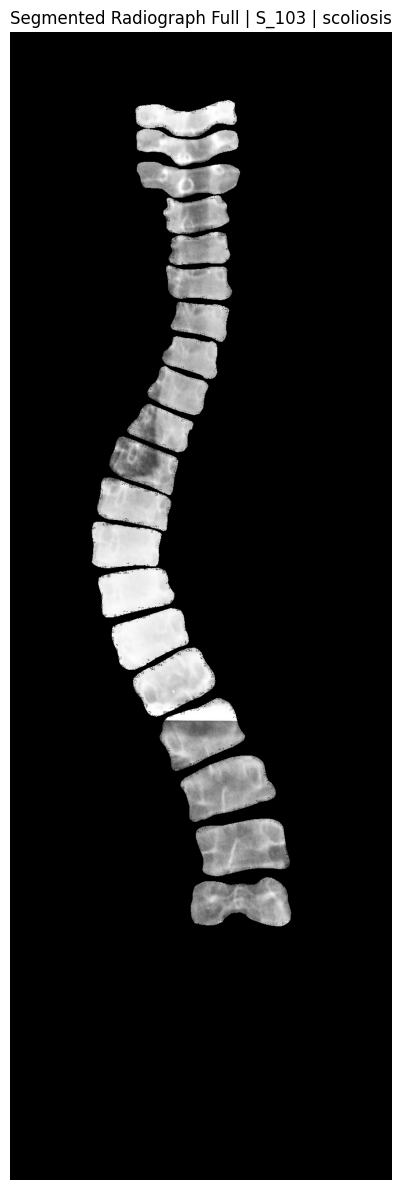

In [26]:
gray_mask_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG/LabelMulti_S_103.jpg"
radiograph_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_103.jpg"

# IMPORTANT: You need to replace these dummy dictionaries with the actual
# class ID to name and class ID to gray value mappings relevant to your dataset.
# For example, if class 1 is 'vertebra_1' and its gray value in the mask is 50,
# and class 2 is 'vertebra_2' with gray value 100:
class_id_to_name = {
    0: "background",
    1: "C7",
    2: "C6",
    3: "C5",
    4: "C4",
    5: "C3",
    6: "T1",
    7: "T2",
    8: "T3",
    9: "T4",
    10: "T5",
    11: "T6",
    12: "T7",
    13: "T8",
    14: "T9",
    15: "T10",
    16: "T11",
    17: "T12",
    18: "L1",
    19: "L2",
    20: "L3",
    21: "L4",
    22: "L5",
}

class_id_to_gray = {
    0: 0,
    1: 8,
    2: 16,
    3: 24,
    4: 32,
    5: 40,
    6: 48,
    7: 56,
    8: 64,
    9: 72,
    10: 80,
    11: 88,
    12: 96,
    13: 104,
    14: 112,
    15: 120,
    16: 128,
    17: 136,
    18: 144,
    19: 152,
    20: 160,
    21: 168,
    22: 176,
}

processor = VertebraGrayImageOnlyProcessor(
    class_id_to_name=class_id_to_name,
    class_id_to_gray=class_id_to_gray
)

# 3) vuelve a cargar/procesar el caso
processor.process_case_from_paths(
    gray_mask_path=gray_mask_path,
    radiograph_path=radiograph_path,
    tolerance=4,
    min_blob_area=10,
    deduplicate=True,
    overlap_threshold=0.80,
    iou_threshold=0.50
)

# 4) ahora sí llama el método
processor.show_segmented_radiograph_full()

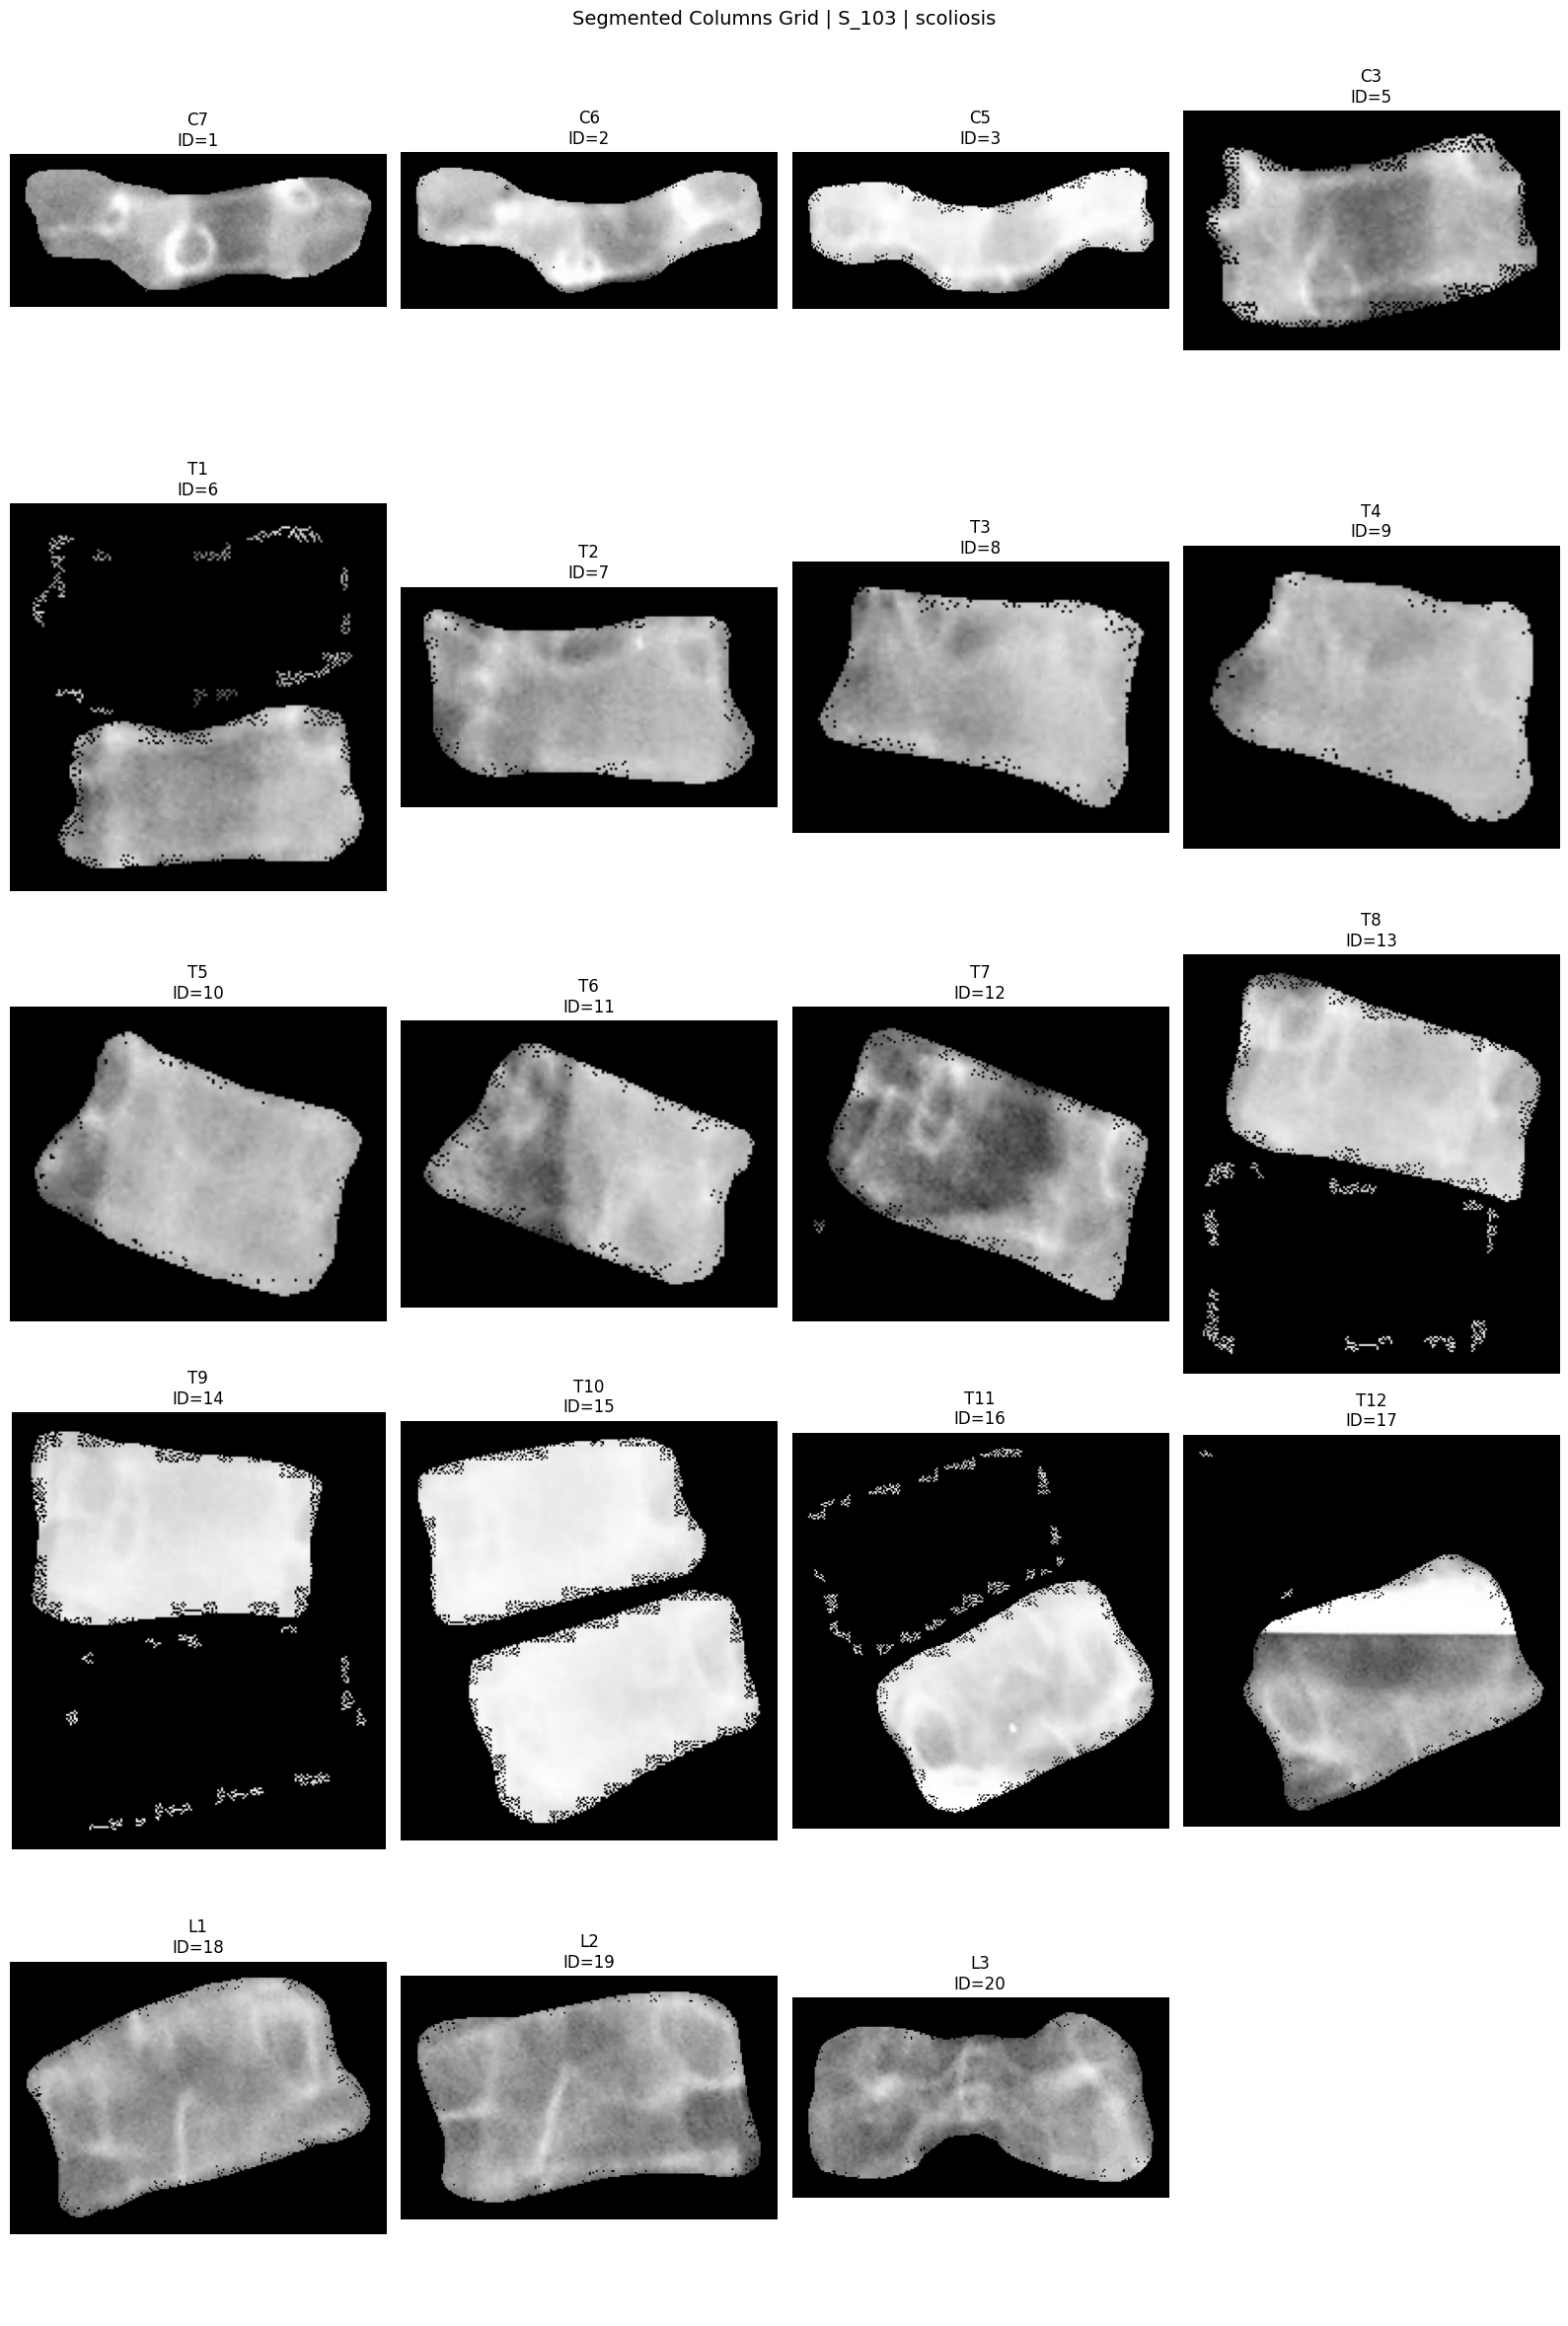

In [ ]:
processor.show_segmented_columns_grid(pad=10, columns=4)

In [27]:
!pip install -q segmentation-models-pytorch timm albumentations opencv-python psutil pynvml pandas matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.0 MB/s eta 0:00:00


In [28]:
%%writefile /content/unet_experiment_service.py
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, List, Tuple
import json
import time
import math
import random
import shutil
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import psutil
import matplotlib.pyplot as plt

try:
    import segmentation_models_pytorch as smp
except Exception:
    smp = None

try:
    from pynvml import (
        nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetUtilizationRates,
        nvmlDeviceGetMemoryInfo, nvmlShutdown
    )
    PYNVML_AVAILABLE = True
except Exception:
    PYNVML_AVAILABLE = False


# =========================
# Config DTO
# =========================

@dataclass
class UNetExperimentConfig:
    experiment_name: str
    drive_root: str
    seed: int
    execution_mode: str
    processor: Dict[str, Any]
    data: Dict[str, Any]
    model: Dict[str, Any]
    training: Dict[str, Any]
    checkpointing: Dict[str, Any]
    reporting: Dict[str, Any]
    runtime: Dict[str, Any]


# =========================
# Placeholder imports expected in notebook/runtime
# =========================
# These names are resolved dynamically from globals() or import scope.
# You can define/import your real classes before creating the service.
#
# class SpineEnhancementAndAdaptiveROIViewer: ...
# class VertebraGrayImageOnlyProcessor: ...


# =========================
# Utility functions
# =========================

def now_iso() -> str:
    return datetime.utcnow().isoformat() + "Z"


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def set_global_seed(seed: int, deterministic: bool = True, benchmark: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = benchmark


def timestamp_str() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


def safe_json_dump(obj: Dict[str, Any], path: Path) -> None:
    def _default(o):
        if isinstance(o, Path):
            return str(o)
        if isinstance(o, (np.integer, np.floating)):
            return o.item()
        return str(o)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=_default)


def append_row_csv(row: Dict[str, Any], path: Path) -> None:
    df = pd.DataFrame([row])
    header = not path.exists()
    df.to_csv(path, mode="a", header=header, index=False)


def resize_image_mask(image: np.ndarray, mask: np.ndarray, image_size: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    image = cv2.resize(image, (w, h), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    return image, mask


def to_uint8_image(x: np.ndarray) -> np.ndarray:
    if x.dtype == np.uint8:
        return x
    x = x.astype(np.float32)
    x_min, x_max = x.min(), x.max()
    if x_max - x_min < 1e-8:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - x_min) / (x_max - x_min)
    return (x * 255).clip(0, 255).astype(np.uint8)


def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


# =========================
# Metrics / losses
# =========================

class DiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        targets = targets.float()
        inter = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * inter + self.eps) / (union + self.eps)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return self.bce(logits, targets.float()) + self.dice(logits, targets)


def build_loss(name: str) -> nn.Module:
    name = name.lower()
    if name == "bce":
        return nn.BCEWithLogitsLoss()
    if name == "dice":
        return DiceLoss()
    if name == "bce_dice":
        return BCEDiceLoss()
    raise ValueError(f"Loss no soportada: {name}")


def _threshold(preds: torch.Tensor, thr: float = 0.5) -> torch.Tensor:
    return (preds > thr).float()


def compute_batch_metrics_from_probs(probs: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> Dict[str, float]:
    preds = _threshold(probs)
    targets = (targets > 0.5).float()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    inter = tp
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - inter

    dice = (2 * inter + eps) / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps)
    iou = (inter + eps) / (union + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)

    return {
        "dice": float(dice.mean().item()),
        "iou": float(iou.mean().item()),
        "precision": float(precision.mean().item()),
        "recall": float(recall.mean().item()),
        "f1": float(f1.mean().item()),
    }


# =========================
# Dataset
# =========================



class SpineProcessorAdapter:
    def __init__(self, processor_cls, params: dict, input_representation: str = "enhanced"):
        self.processor_cls = processor_cls
        self.params = params or {}
        self.input_representation = input_representation

    def process_single(self, image_path: str, mask_path: str):
        result = self.processor_cls.process(
            radiograph_path=image_path,
            binary_mask_path=mask_path,
            show=False,
            **self.params
        )

        target_map = {
            "original": "refined_mask",
            "enhanced": "refined_mask",
            "refined_mask": "refined_mask",
            "roi_rect_crop": "target_rect_crop",
            "roi_adaptive_masked": "target_adaptive_masked",
            "roi_adaptive_crop": "target_adaptive_crop",
        }

        image = result.get(self.input_representation)
        if image is None:
            raise ValueError(
                f"Representación no disponible: {self.input_representation}. "
                f"Disponibles: {list(result.keys())}"
            )

        mask_key = target_map.get(self.input_representation, "refined_mask")
        mask = result.get(mask_key)
        if mask is None:
            raise ValueError(
                f"Target no disponible para '{self.input_representation}'. "
                f"Se esperaba '{mask_key}'. Disponibles: {list(result.keys())}"
            )

        return {
            "image": image,
            "mask": mask,
            **result
        }



class VertebraProcessorAdapter:
    def __init__(self, processor_cls, params: dict):
        self.processor_cls = processor_cls
        self.params = params or {}

    def process_single(self, image_path: str, mask_path: str):
        processor = self.processor_cls(**self.params)
        result = processor.process_single(image_path=image_path, mask_path=mask_path)

        return {
            "image": result.get("segmented_gray", result.get("image")),
            "mask": result.get("binary_mask", result.get("mask")),
            **result
        }

class ScoliosisSegmentationDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        base_dir: Path,
        image_column: str,
        mask_column: str,
        patient_id_column: str,
        processor: Any,
        image_size: Tuple[int, int],
        normalize: bool = True,
        input_representation: str = "enhanced",
    ):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.image_column = image_column
        self.mask_column = mask_column
        self.patient_id_column = patient_id_column
        self.processor = processor
        self.image_size = image_size
        self.normalize = normalize
        self.input_representation = input_representation

    def __len__(self) -> int:
        return len(self.df)

    def _read_raw(self, idx: int) -> Tuple[str, str]:
        row = self.df.iloc[idx]
        image_path = str(self.base_dir / row[self.image_column])
        mask_path = str(self.base_dir / row[self.mask_column])
        return image_path, mask_path

    def _extract_processed(self, result: Dict[str, Any], image_path: str, mask_path: str) -> Tuple[np.ndarray, np.ndarray]:
        image = None
        mask = None

        for k in [
            "image",
            "roi_adaptive_crop",
            "roi_rect_crop",
            "enhanced",
            "segmented_gray",
            "processed_image"
        ]:
            if k in result and result[k] is not None:
                image = result[k]
                break

        for k in [
            "mask",
            "adaptive_band",
            "refined_mask",
            "binary_mask",
            "processed_mask"
        ]:
            if k in result and result[k] is not None:
                mask = result[k]
                break

        if image is None:
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"No se pudo cargar imagen: {image_path}")
        if mask is None:
            raise ValueError(f"No se pudo cargar máscara: {mask_path}")

        return image, mask

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]
        image_path, mask_path = self._read_raw(idx)

        if hasattr(self.processor, "process_single"):
            result = self.processor.process_single(image_path=image_path, mask_path=mask_path)
        elif hasattr(self.processor, "process"):
            result = self.processor.process(image_path=image_path, mask_path=mask_path)
        else:
            raise ValueError("El processor debe tener process_single(...) o process(...)")

        image, mask = self._extract_processed(result, image_path, mask_path)

        image = np.asarray(image)
        mask = np.asarray(mask)

        if image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        if mask.ndim == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

        image, mask = resize_image_mask(image, mask, self.image_size)

        image = image.astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        if self.normalize:
            if image.max() > 1.0:
                image = image / 255.0

        image_t = torch.tensor(image[None, ...], dtype=torch.float32)
        mask_t = torch.tensor(mask[None, ...], dtype=torch.float32)

        return {
            "image": image_t,
            "mask": mask_t,
            "patient_id": str(row[self.patient_id_column]),
            "sample_id": str(row.get("image", idx)),
            "image_path": image_path,
            "mask_path": mask_path,
            "image_np": image,
            "mask_np": mask,
        }


# =========================
# Main experiment service
# =========================

class UNetExperimentService:
    def __init__(self, config: UNetExperimentConfig):
        self.config = config
        device_name = self.config.runtime.get("device", "cuda")
        self.device = torch.device(device_name if torch.cuda.is_available() else "cpu")

        self.experiment_dir: Optional[Path] = None
        self.model: Optional[nn.Module] = None
        self.optimizer = None
        self.scheduler = None
        self.loss_fn: Optional[nn.Module] = None
        self.best_metric_value: Optional[float] = None
        self.best_epoch: Optional[int] = None
        self.best_metric_name: str = self.config.training.get("best_metric_name", "dice")

        self.processor = None
        self.train_df = None
        self.val_df = None
        self.test_df = None
        self.train_loader = None
        self.val_loader = None
        self.test_loader = None

        self.state: Dict[str, Any] = {
            "status": "pending",
            "resumed_from_checkpoint": False,
            "resume_checkpoint_path": None,
            "current_fold": 1,
            "total_folds": 1,
            "current_model": self.config.model.get("model_name", "unet"),
        }

        self.resource_csv_path = None
        self.epoch_csv_path = None

        self.feature_map_cache: Dict[str, torch.Tensor] = {}
        self.hooks: List[Any] = []
        self.tracked_indices: List[int] = []

    # -------------------------
    # public API
    # -------------------------

    def run(self) -> Dict[str, Any]:
        self._set_seed(self.config.seed)
        self._prepare_directories()
        self._save_config()
        self._build_processor()
        self._build_datasets()
        self._build_model()
        self._build_training_components()

        self.state["experiment_start_time"] = now_iso()
        self.state["model_start_time"] = now_iso()
        self.state["status"] = "running"
        self._save_state_json()

        try:
            self._train()
            test_metrics = self._test()
            self.state["test_metrics"] = test_metrics
            self.state["status"] = "completed"
        except KeyboardInterrupt:
            self.state["status"] = "interrupted"
            self._save_checkpoint(self.state.get("current_epoch", 0), tag="interrupt_checkpoint")
            raise
        except Exception as e:
            self.state["status"] = "failed"
            self.state["error"] = str(e)
            self._save_checkpoint(self.state.get("current_epoch", 0), tag="interrupt_checkpoint")
            raise
        finally:
            self.state["model_end_time"] = now_iso()
            self.state["experiment_end_time"] = now_iso()
            self._compute_final_durations()
            self._save_state_json()
            self._finalize_summary()
            self._remove_hooks()

        return self.state

    def resume(self, checkpoint_path: str) -> Dict[str, Any]:
        self._set_seed(self.config.seed)
        self._prepare_directories(resume=True)
        self._save_config()
        self._build_processor()
        self._build_datasets()
        self._build_model()
        self._build_training_components()
        self._load_checkpoint(checkpoint_path)

        self.state["resumed_from_checkpoint"] = True
        self.state["resume_checkpoint_path"] = checkpoint_path
        self.state["status"] = "running"
        self._save_state_json()

        try:
            self._train(resume=True)
            test_metrics = self._test()
            self.state["test_metrics"] = test_metrics
            self.state["status"] = "completed"
        except KeyboardInterrupt:
            self.state["status"] = "interrupted"
            self._save_checkpoint(self.state.get("current_epoch", 0), tag="interrupt_checkpoint")
            raise
        except Exception as e:
            self.state["status"] = "failed"
            self.state["error"] = str(e)
            self._save_checkpoint(self.state.get("current_epoch", 0), tag="interrupt_checkpoint")
            raise
        finally:
            self.state["model_end_time"] = now_iso()
            self.state["experiment_end_time"] = now_iso()
            self._compute_final_durations()
            self._save_state_json()
            self._finalize_summary()
            self._remove_hooks()

        return self.state

    # -------------------------
    # setup
    # -------------------------

    def _set_seed(self, seed: int) -> None:
        deterministic = self.config.runtime.get("deterministic", True)
        benchmark = self.config.runtime.get("benchmark", False)
        set_global_seed(seed, deterministic=deterministic, benchmark=benchmark)

    def _prepare_directories(self, resume: bool = False) -> None:
        if self.experiment_dir is None:
            timestamp = timestamp_str()
            self.experiment_dir = Path(self.config.drive_root) / f"{self.config.experiment_name}_{timestamp}"

        subdirs = [
            "",
            "checkpoints",
            "logs",
            "visualizations/tracked_samples",
            "visualizations/feature_maps",
            "visualizations/filters",
            "visualizations/overlays",
            "visualizations/error_maps",
            "test_outputs",
        ]
        for subdir in subdirs:
            ensure_dir(self.experiment_dir / subdir)

        self.resource_csv_path = self.experiment_dir / "logs" / "resource_usage.csv"
        self.epoch_csv_path = self.experiment_dir / "logs" / "epoch_metrics.csv"

    def _save_config(self) -> None:
        path = self.experiment_dir / "config.json"
        safe_json_dump(self.config.__dict__, path)

    def _build_processor(self) -> None:
        processor_type = self.config.processor["type"]
        params = self.config.processor.get("params", {})
        input_representation = self.config.data.get("input_representation", "enhanced")

        if processor_type == "SpineEnhancementAndAdaptiveROIViewer":
            if "SpineEnhancementAndAdaptiveROIViewer" not in globals():
                raise ValueError("No existe SpineEnhancementAndAdaptiveROIViewer en el entorno actual.")
            self.processor = SpineProcessorAdapter(
                globals()["SpineEnhancementAndAdaptiveROIViewer"],
                params,
                input_representation=input_representation
            )

        elif processor_type == "VertebraGrayImageOnlyProcessor":
            if "VertebraGrayImageOnlyProcessor" not in globals():
                raise ValueError("No existe VertebraGrayImageOnlyProcessor en el entorno actual.")
            self.processor = VertebraProcessorAdapter(
                globals()["VertebraGrayImageOnlyProcessor"],
                params
            )

        else:
            raise ValueError(f"Processor no soportado: {processor_type}")

    def _build_datasets(self) -> None:
        data_cfg = self.config.data
        base_dir = Path(data_cfg["base_dir"])
        index_csv = Path(data_cfg["index_csv"])
        input_representation = data_cfg.get("input_representation", "enhanced")

        df = pd.read_csv(index_csv)

        # split logic
        split_column = data_cfg.get("split_column", None)
        train_val_test_present = False
        if split_column is not None and split_column in df.columns:
            unique_vals = set(df[split_column].dropna().astype(str).unique().tolist())
            train_val_test_present = {"train", "val", "test"}.issubset(unique_vals)

        if train_val_test_present:
            self.train_df = df[df[split_column].astype(str) == "train"].copy()
            self.val_df = df[df[split_column].astype(str) == "val"].copy()
            self.test_df = df[df[split_column].astype(str) == "test"].copy()
        else:
            # fallback split
            df = df.sample(frac=1.0, random_state=self.config.seed).reset_index(drop=True)
            n = len(df)
            n_train = int(0.70 * n)
            n_val = int(0.15 * n)
            self.train_df = df.iloc[:n_train].copy()
            self.val_df = df.iloc[n_train:n_train + n_val].copy()
            self.test_df = df.iloc[n_train + n_val:].copy()

        image_column = data_cfg["image_column"]
        mask_column = data_cfg["mask_column"]
        patient_id_column = data_cfg["patient_id_column"]
        image_size = tuple(data_cfg.get("image_size", [512, 256]))
        normalize = bool(data_cfg.get("normalize", True))

        train_ds = ScoliosisSegmentationDataset(
            self.train_df, base_dir, image_column, mask_column, patient_id_column,
            processor=self.processor, image_size=image_size, normalize=normalize,
            input_representation=input_representation
        )
        val_ds = ScoliosisSegmentationDataset(
            self.val_df, base_dir, image_column, mask_column, patient_id_column,
            processor=self.processor, image_size=image_size, normalize=normalize,
            input_representation=input_representation
        )
        test_ds = ScoliosisSegmentationDataset(
            self.test_df, base_dir, image_column, mask_column, patient_id_column,
            processor=self.processor, image_size=image_size, normalize=normalize,
            input_representation=input_representation
        )

        num_workers = int(self.config.training.get("num_workers", 2))
        batch_size = int(self.config.training.get("batch_size", 8))
        pin_memory = bool(self.config.training.get("pin_memory", True))

        self.train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
        self.val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
        self.test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

        tracked_sample_count = int(self.config.reporting.get("tracked_sample_count", 4))
        self.tracked_indices = list(range(min(tracked_sample_count, len(val_ds))))

        self.state["num_workers"] = num_workers
        self.state["batch_size"] = batch_size
        self.state["train_size"] = len(train_ds)
        self.state["val_size"] = len(val_ds)
        self.state["test_size"] = len(test_ds)

    def _build_model(self) -> None:
        if smp is None:
            raise ImportError("segmentation_models_pytorch no está instalado.")

        model_cfg = self.config.model
        model_name = model_cfg.get("model_name", "unet").lower()
        if model_name != "unet":
            raise ValueError(f"Esta clase solo soporta U-Net. Se recibió: {model_name}")

        self.model = smp.Unet(
            encoder_name=model_cfg.get("encoder_name", "resnet34"),
            encoder_weights=model_cfg.get("encoder_weights", "imagenet"),
            in_channels=int(model_cfg.get("in_channels", 1)),
            classes=int(model_cfg.get("classes", 1)),
            activation=model_cfg.get("activation", None),
        ).to(self.device)

        self._register_feature_hooks()

    def _build_training_components(self) -> None:
        tr_cfg = self.config.training
        lr = float(tr_cfg.get("learning_rate", 3e-4))
        opt_name = str(tr_cfg.get("optimizer", "adamw")).lower()
        scheduler_name = str(tr_cfg.get("scheduler", "cosine")).lower()
        loss_name = str(tr_cfg.get("loss", "bce_dice")).lower()

        if opt_name == "adam":
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        elif opt_name == "adamw":
            self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        elif opt_name == "sgd":
            self.optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=0.9)
        else:
            raise ValueError(f"Optimizer no soportado: {opt_name}")

        epochs = int(tr_cfg.get("epochs", 20))
        if scheduler_name == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=epochs)
        elif scheduler_name == "plateau":
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode="min", patience=3)
        elif scheduler_name == "none":
            self.scheduler = None
        else:
            self.scheduler = None

        self.loss_fn = build_loss(loss_name)
        self.best_metric_value = -1.0 if self.best_metric_name != "val_loss" else float("inf")

    # -------------------------
    # train / validate / test
    # -------------------------

    def _train(self, resume: bool = False) -> None:
        epochs = int(self.config.training.get("epochs", 20))
        save_every_n_epochs = int(self.config.reporting.get("save_visual_every_n_epochs", 5))
        checkpoint_every = int(self.config.checkpointing.get("epoch_checkpoint_frequency", 5))

        start_epoch = int(self.state.get("current_epoch", 0)) + 1 if resume else 1
        self.state["total_epochs"] = epochs

        epoch_durations = []

        for epoch in range(start_epoch, epochs + 1):
            self.state["current_epoch"] = epoch
            self.state["epoch_start_time"] = now_iso()
            epoch_t0 = time.time()

            train_metrics = self._run_one_epoch_train(epoch)
            val_metrics = self._validate(epoch)

            epoch_duration_sec = time.time() - epoch_t0
            epoch_durations.append(epoch_duration_sec)
            avg_epoch_duration_sec = float(np.mean(epoch_durations))
            estimated_remaining_sec = avg_epoch_duration_sec * (epochs - epoch)

            current_metric = val_metrics.get(self.best_metric_name, None)
            improved = False
            if current_metric is not None:
                if self.best_metric_name == "val_loss":
                    if current_metric < self.best_metric_value:
                        improved = True
                else:
                    if current_metric > self.best_metric_value:
                        improved = True

            if improved:
                self.best_metric_value = current_metric
                self.best_epoch = epoch
                self.state["best_epoch"] = epoch
                self.state["best_metric_name"] = self.best_metric_name
                self.state["best_metric_value"] = float(current_metric)
                self._save_checkpoint(epoch, tag="best_model")

            self._save_checkpoint(epoch, tag="last_model")

            if bool(self.config.checkpointing.get("save_epoch_checkpoints", True)) and epoch % checkpoint_every == 0:
                self._save_checkpoint(epoch, tag=f"epoch_{epoch}")

            # visualize selected epochs
            if epoch == 1 or epoch == epochs or epoch == self.best_epoch or epoch % save_every_n_epochs == 0:
                self._save_visual_report_grid(epoch)
                if bool(self.config.reporting.get("save_feature_maps", True)):
                    self._save_feature_maps(epoch)
                if bool(self.config.reporting.get("save_filters", True)):
                    self._save_filters(epoch)

            # log row
            lr = float(self.optimizer.param_groups[0]["lr"])
            row = {
                "epoch": epoch,
                **train_metrics,
                **val_metrics,
                "lr": lr,
                "epoch_duration_sec": epoch_duration_sec,
                "avg_epoch_duration_sec": avg_epoch_duration_sec,
                "estimated_remaining_sec": estimated_remaining_sec,
            }
            append_row_csv(row, self.epoch_csv_path)

            # resource row
            resource_row = self._collect_system_metrics()
            resource_row.update({
                "timestamp": now_iso(),
                "model_name": self.config.model.get("model_name", "unet"),
                "fold": 1,
                "epoch": epoch,
                "batch_size": self.config.training.get("batch_size", 8),
                "num_workers": self.config.training.get("num_workers", 2),
                "samples_per_sec": train_metrics.get("samples_per_sec"),
                "steps_per_sec": train_metrics.get("steps_per_sec"),
            })
            append_row_csv(resource_row, self.resource_csv_path)

            # update state
            self.state.update({
                "epoch_end_time": now_iso(),
                "epoch_duration_sec": epoch_duration_sec,
                "avg_epoch_duration_sec": avg_epoch_duration_sec,
                "estimated_remaining_sec": estimated_remaining_sec,
                "last_completed_step": "epoch_end",
                "checkpoint_saved_at": now_iso(),
            })
            self.state.update(resource_row)
            self._save_state_json()

            # scheduler
            if self.scheduler is not None:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_metrics["val_loss"])
                else:
                    self.scheduler.step()

            print(
                f"[Epoch {epoch}/{epochs}] "
                f"train_loss={train_metrics['train_loss']:.4f} "
                f"val_loss={val_metrics['val_loss']:.4f} "
                f"dice={val_metrics['dice']:.4f} "
                f"iou={val_metrics['iou']:.4f}"
            )

    def _run_one_epoch_train(self, epoch: int) -> Dict[str, Any]:
        self.model.train()
        total_loss = 0.0
        all_metrics = []
        n_samples = 0

        t0 = time.time()
        for batch in self.train_loader:
            images = batch["image"].to(self.device, non_blocking=True)
            masks = batch["mask"].to(self.device, non_blocking=True)

            self.optimizer.zero_grad()
            logits = self.model(images)
            loss = self.loss_fn(logits, masks)
            loss.backward()
            self.optimizer.step()

            probs = torch.sigmoid(logits)
            metrics = compute_batch_metrics_from_probs(probs, masks)

            total_loss += loss.item()
            all_metrics.append(metrics)
            n_samples += images.size(0)

        elapsed = time.time() - t0
        mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in all_metrics[0].keys()} if all_metrics else {}
        return {
            "train_loss": total_loss / max(1, len(self.train_loader)),
            **mean_metrics,
            "samples_per_sec": n_samples / max(elapsed, 1e-8),
            "steps_per_sec": len(self.train_loader) / max(elapsed, 1e-8),
        }

    @torch.no_grad()
    def _validate(self, epoch: int) -> Dict[str, Any]:
        self.model.eval()
        total_loss = 0.0
        all_metrics = []

        fold_t0 = time.time()
        self.state["fold_start_time"] = now_iso()

        for batch in self.val_loader:
            images = batch["image"].to(self.device, non_blocking=True)
            masks = batch["mask"].to(self.device, non_blocking=True)

            logits = self.model(images)
            loss = self.loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            all_metrics.append(compute_batch_metrics_from_probs(probs, masks))

        fold_duration_sec = time.time() - fold_t0
        mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in all_metrics[0].keys()} if all_metrics else {}

        self.state["fold_end_time"] = now_iso()
        self.state["fold_duration_sec"] = fold_duration_sec

        return {
            "val_loss": total_loss / max(1, len(self.val_loader)),
            **mean_metrics,
        }

    @torch.no_grad()
    def _test(self) -> Dict[str, Any]:
        self.model.eval()
        total_loss = 0.0
        all_metrics = []
        sample_rows = []

        for batch in self.test_loader:
            images = batch["image"].to(self.device, non_blocking=True)
            masks = batch["mask"].to(self.device, non_blocking=True)
            logits = self.model(images)
            loss = self.loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            batch_metrics = compute_batch_metrics_from_probs(probs, masks)
            all_metrics.append(batch_metrics)

            preds = (probs > 0.5).float().cpu().numpy()
            for i in range(images.size(0)):
                sample_rows.append({
                    "sample_id": batch["sample_id"][i],
                    "patient_id": batch["patient_id"][i],
                    "prediction_mean": float(preds[i].mean()),
                })

        mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in all_metrics[0].keys()} if all_metrics else {}
        summary = {
            "test_loss": total_loss / max(1, len(self.test_loader)),
            **mean_metrics,
        }
        safe_json_dump(summary, self.experiment_dir / "test_outputs" / "test_summary.json")
        pd.DataFrame(sample_rows).to_csv(self.experiment_dir / "test_outputs" / "predictions.csv", index=False)
        return summary

    # -------------------------
    # checkpoints / state
    # -------------------------

    def _save_checkpoint(self, epoch: int, tag: str) -> None:
        ckpt_path = self.experiment_dir / "checkpoints" / f"{tag}.pt"
        payload = {
            "epoch": epoch,
            "seed": self.config.seed,
            "best_epoch": self.best_epoch,
            "best_metric_name": self.best_metric_name,
            "best_metric_value": self.best_metric_value,
            "timestamp": now_iso(),
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict() if self.optimizer is not None else None,
            "scheduler_state_dict": self.scheduler.state_dict() if self.scheduler is not None else None,
            "config": self.config.__dict__,
        }
        torch.save(payload, ckpt_path)

    def _load_checkpoint(self, checkpoint_path: str) -> None:
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        if self.optimizer is not None and ckpt.get("optimizer_state_dict") is not None:
            self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if self.scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
            self.scheduler.load_state_dict(ckpt["scheduler_state_dict"])

        self.state["current_epoch"] = int(ckpt.get("epoch", 0))
        self.best_epoch = ckpt.get("best_epoch", None)
        self.best_metric_name = ckpt.get("best_metric_name", self.best_metric_name)
        self.best_metric_value = ckpt.get("best_metric_value", self.best_metric_value)

    def _save_state_json(self) -> None:
        path = self.experiment_dir / "experiment_state.json"
        safe_json_dump(self.state, path)

    def _compute_final_durations(self) -> None:
        try:
            exp_start = datetime.fromisoformat(self.state["experiment_start_time"].replace("Z", ""))
            exp_end = datetime.fromisoformat(self.state["experiment_end_time"].replace("Z", ""))
            self.state["experiment_duration_sec"] = (exp_end - exp_start).total_seconds()
        except Exception:
            pass

        try:
            model_start = datetime.fromisoformat(self.state["model_start_time"].replace("Z", ""))
            model_end = datetime.fromisoformat(self.state["model_end_time"].replace("Z", ""))
            self.state["model_duration_sec"] = (model_end - model_start).total_seconds()
        except Exception:
            pass

    # -------------------------
    # system metrics
    # -------------------------

    def _collect_system_metrics(self) -> Dict[str, Any]:
        ram = psutil.virtual_memory()
        disk = psutil.disk_usage(str(self.experiment_dir))

        gpu_name = None
        gpu_memory_used_mb = None
        gpu_memory_reserved_mb = None
        gpu_memory_total_mb = None
        gpu_utilization_percent = None

        if torch.cuda.is_available():
            gpu_name = torch.cuda.get_device_name(0)
            gpu_memory_used_mb = round(torch.cuda.memory_allocated(0) / (1024 ** 2), 2)
            gpu_memory_reserved_mb = round(torch.cuda.memory_reserved(0) / (1024 ** 2), 2)
            gpu_memory_total_mb = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 2), 2)

            if PYNVML_AVAILABLE:
                try:
                    nvmlInit()
                    handle = nvmlDeviceGetHandleByIndex(0)
                    util = nvmlDeviceGetUtilizationRates(handle)
                    mem = nvmlDeviceGetMemoryInfo(handle)
                    gpu_utilization_percent = util.gpu
                    gpu_memory_used_mb = round(mem.used / (1024 ** 2), 2)
                    gpu_memory_total_mb = round(mem.total / (1024 ** 2), 2)
                    nvmlShutdown()
                except Exception:
                    pass

        return {
            "cpu_percent": psutil.cpu_percent(),
            "ram_used_mb": round(ram.used / (1024 ** 2), 2),
            "ram_total_mb": round(ram.total / (1024 ** 2), 2),
            "ram_percent": ram.percent,
            "gpu_name": gpu_name,
            "gpu_memory_used_mb": gpu_memory_used_mb,
            "gpu_memory_reserved_mb": gpu_memory_reserved_mb,
            "gpu_memory_total_mb": gpu_memory_total_mb,
            "gpu_utilization_percent": gpu_utilization_percent,
            "disk_free_gb": round(disk.free / (1024 ** 3), 2),
        }

    # -------------------------
    # visualizations
    # -------------------------

    def _register_feature_hooks(self) -> None:
        self._remove_hooks()
        self.feature_map_cache = {}

        # register a few representative hooks
        modules = []
        try:
            if hasattr(self.model, "encoder"):
                for i, block in enumerate(self.model.encoder.children()):
                    modules.append((f"encoder_{i}", block))
        except Exception:
            pass

        if not modules:
            # fallback: first few convs
            count = 0
            for name, module in self.model.named_modules():
                if isinstance(module, (nn.Conv2d, nn.MaxPool2d)):
                    modules.append((name.replace(".", "_"), module))
                    count += 1
                if count >= 6:
                    break

        def hook_fn(name):
            def _hook(module, inp, out):
                try:
                    if isinstance(out, (tuple, list)):
                        out = out[0]
                    if torch.is_tensor(out):
                        self.feature_map_cache[name] = out.detach().cpu()
                except Exception:
                    pass
            return _hook

        for name, module in modules[:8]:
            self.hooks.append(module.register_forward_hook(hook_fn(name)))

    def _remove_hooks(self) -> None:
        for h in self.hooks:
            try:
                h.remove()
            except Exception:
                pass
        self.hooks = []

    @torch.no_grad()
    def _save_visual_report_grid(self, epoch: int) -> None:
        self.model.eval()
        ds = self.val_loader.dataset

        rows = []
        for idx in self.tracked_indices:
            sample = ds[idx]
            image_t = sample["image"].unsqueeze(0).to(self.device)
            mask_np = sample["mask_np"]

            logits = self.model(image_t)
            pred = torch.sigmoid(logits)[0, 0].cpu().numpy()
            pred_bin = (pred > 0.5).astype(np.uint8)

            image_np = sample["image_np"]
            image_u8 = to_uint8_image(image_np)
            gt_u8 = to_uint8_image(mask_np * 255)
            pred_u8 = to_uint8_image(pred_bin * 255)

            overlay = cv2.cvtColor(image_u8, cv2.COLOR_GRAY2BGR)
            overlay[..., 1] = np.maximum(overlay[..., 1], pred_u8)  # green pred
            overlay[..., 2] = np.maximum(overlay[..., 2], gt_u8)    # red gt

            error_map = np.abs(mask_np.astype(np.float32) - pred_bin.astype(np.float32))
            error_u8 = to_uint8_image(error_map * 255)

            rows.append([
                image_u8, image_u8, gt_u8, pred_u8,
                cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB),
                error_u8
            ])

        if not rows:
            return

        n_rows = len(rows)
        titles = ["original", "preprocessed", "ground_truth", "prediction", "overlay", "error_map"]
        fig, axes = plt.subplots(n_rows, len(titles), figsize=(3 * len(titles), 3 * n_rows))
        if n_rows == 1:
            axes = np.expand_dims(axes, axis=0)

        for r in range(n_rows):
            for c in range(len(titles)):
                ax = axes[r, c]
                img = rows[r][c]
                if img.ndim == 2:
                    ax.imshow(img, cmap="gray")
                else:
                    ax.imshow(img)
                ax.axis("off")
                if r == 0:
                    ax.set_title(titles[c])

        fig.suptitle(f"Epoch {epoch} report grid", fontsize=14)
        plt.tight_layout()
        out_path = self.experiment_dir / "visualizations" / "tracked_samples" / f"epoch_{epoch:03d}_report_grid.png"
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

    @torch.no_grad()
    def _save_feature_maps(self, epoch: int) -> None:
        self.model.eval()
        ds = self.val_loader.dataset
        if len(self.tracked_indices) == 0:
            return

        sample = ds[self.tracked_indices[0]]
        image_t = sample["image"].unsqueeze(0).to(self.device)

        self.feature_map_cache = {}
        _ = self.model(image_t)

        max_maps = int(self.config.reporting.get("max_feature_maps_per_layer", 8))
        out_dir = self.experiment_dir / "visualizations" / "feature_maps" / f"epoch_{epoch:03d}"
        ensure_dir(out_dir)

        for layer_name, feat in self.feature_map_cache.items():
            if feat.ndim != 4:
                continue
            fmap = feat[0]
            n = min(max_maps, fmap.shape[0])

            cols = min(4, n)
            rows = math.ceil(n / cols)
            fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
            axes = np.array(axes).reshape(rows, cols)

            for i in range(rows * cols):
                ax = axes.flat[i]
                ax.axis("off")
                if i < n:
                    fm = fmap[i].numpy()
                    ax.imshow(fm, cmap="gray")
                    ax.set_title(f"{layer_name}_{i}", fontsize=8)

            plt.tight_layout()
            plt.savefig(out_dir / f"{layer_name}.png", dpi=150, bbox_inches="tight")
            plt.close(fig)

    def _save_filters(self, epoch: int) -> None:
        max_filters = int(self.config.reporting.get("max_filters_to_plot", 16))
        out_dir = self.experiment_dir / "visualizations" / "filters" / f"epoch_{epoch:03d}"
        ensure_dir(out_dir)

        saved_any = False
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                w = module.weight.detach().cpu().numpy()  # [out_ch, in_ch, k, k]
                n = min(max_filters, w.shape[0])

                cols = min(4, n)
                rows = math.ceil(n / cols)
                fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
                axes = np.array(axes).reshape(rows, cols)

                for i in range(rows * cols):
                    ax = axes.flat[i]
                    ax.axis("off")
                    if i < n:
                        filt = w[i, 0]
                        ax.imshow(filt, cmap="gray")
                        ax.set_title(f"{i}", fontsize=8)

                plt.tight_layout()
                safe_name = name.replace(".", "_")
                plt.savefig(out_dir / f"{safe_name}.png", dpi=150, bbox_inches="tight")
                plt.close(fig)
                saved_any = True
                break  # first conv layer is enough for MVP

        if not saved_any:
            # create marker file
            with open(out_dir / "no_filters_saved.txt", "w") as f:
                f.write("No Conv2d filters found.")

    # -------------------------
    # summaries
    # -------------------------

    def _finalize_summary(self) -> None:
        summary_path = self.experiment_dir / "experiment_summary.json"
        safe_json_dump(self.state, summary_path)

Overwriting /content/unet_experiment_service.py


In [29]:
import json, os
from pathlib import Path

config_dict = {
    "experiment_name": "unet_spine_roi_v1",
    "drive_root": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/resultados_experimentos",
    "seed": 42,
    "execution_mode": "spine_enhancement",

    "processor": {
        "type": "SpineEnhancementAndAdaptiveROIViewer",
        "params": {
            "bbox_pad_ratio": 0.08,
            "band_width_ratio": 0.18
        }
    },

    "data": {
        "base_dir": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset",
        "index_csv": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/dataset_index.csv",
        "split_column": "split",
        "patient_id_column": "patient_id",
        "image_column": "radiograph_path",
        "mask_column": "label_binary_path",
        "image_size": [512, 256],
        "normalize": True,
        "input_representation": "roi_rect_crop"
    },

    "model": {
        "model_name": "unet",
        "in_channels": 1,
        "classes": 1,
        "encoder_name": "resnet34",
        "encoder_weights": "imagenet",
        "activation": None
    },

    "training": {
        "epochs": 20,
        "batch_size": 8,
        "learning_rate": 0.0003,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "loss": "bce_dice",
        "num_workers": 2,
        "mixed_precision": False,
        "pin_memory": True,
        "best_metric_name": "dice"
    },

    "checkpointing": {
        "save_best": True,
        "save_last": True,
        "save_interrupt_checkpoint": True,
        "save_epoch_checkpoints": True,
        "epoch_checkpoint_frequency": 5
    },

    "reporting": {
        "save_visual_every_n_epochs": 5,
        "tracked_sample_count": 4,
        "save_feature_maps": True,
        "save_filters": True,
        "max_feature_maps_per_layer": 8,
        "max_filters_to_plot": 16
    },

    "runtime": {
        "device": "cuda",
        "deterministic": True,
        "benchmark": False
    }
}

cfg_path = Path("/content/drive/MyDrive/MaIA_Scoliosis_Dataset/configs")
cfg_path.mkdir(parents=True, exist_ok=True)

with open(cfg_path / "unet_spine.json", "w", encoding="utf-8") as f:
    json.dump(config_dict, f, indent=2, ensure_ascii=False)

print(cfg_path / "unet_spine.json")

/content/drive/MyDrive/MaIA_Scoliosis_Dataset/configs/unet_spine.json


In [30]:
config_dict_vertebra = {
    "experiment_name": "unet_vertebra_gray_v1",
    "drive_root": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/resultados_experimentos",
    "seed": 42,
    "execution_mode": "vertebra_gray",

    "processor": {
        "type": "VertebraGrayImageOnlyProcessor",
        "params": {
            "use_multiclass_gray": True,
            "use_multiclass_id": False,
            "keep_largest_component": True,
            "min_component_area": 20,
            "pad": 8
        }
    },

    "data": {
        "base_dir": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset",
        "index_csv": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/dataset_index.csv",
        "split_column": "split",
        "patient_id_column": "patient_id",
        "image_column": "radiograph_path",
        "mask_column": "multiclass_gray_jpg",
        "image_size": [256, 256],
        "normalize": True
    },

    "model": {
        "model_name": "unet",
        "in_channels": 1,
        "classes": 1,
        "encoder_name": "resnet34",
        "encoder_weights": "imagenet",
        "activation": None
    },

    "training": {
        "epochs": 20,
        "batch_size": 16,
        "learning_rate": 0.0003,
        "optimizer": "adamw",
        "scheduler": "cosine",
        "loss": "bce_dice",
        "num_workers": 2,
        "mixed_precision": False,
        "pin_memory": True,
        "best_metric_name": "dice"
    },

    "checkpointing": {
        "save_best": True,
        "save_last": True,
        "save_interrupt_checkpoint": True,
        "save_epoch_checkpoints": True,
        "epoch_checkpoint_frequency": 5
    },

    "reporting": {
        "save_visual_every_n_epochs": 5,
        "tracked_sample_count": 4,
        "save_feature_maps": True,
        "save_filters": True,
        "max_feature_maps_per_layer": 8,
        "max_filters_to_plot": 16
    },

    "runtime": {
        "device": "cuda",
        "deterministic": True,
        "benchmark": False
    }
}

with open(cfg_path / "unet_vertebra.json", "w", encoding="utf-8") as f:
    json.dump(config_dict_vertebra, f, indent=2, ensure_ascii=False)

print(cfg_path / "unet_vertebra.json")

/content/drive/MyDrive/MaIA_Scoliosis_Dataset/configs/unet_vertebra.json


In [31]:
from pathlib import Path
import json
import importlib # Import importlib
from unet_experiment_service import UNetExperimentService, UNetExperimentConfig
import unet_experiment_service as ues

# Reload the module to ensure the latest changes are used
importlib.reload(ues)

ues.SpineEnhancementAndAdaptiveROIViewer = SpineEnhancementAndAdaptiveROIViewer
ues.VertebraGrayImageOnlyProcessor = VertebraGrayImageOnlyProcessor

config_path = "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/configs/unet_spine.json"

with open(config_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

# Fix: Remove 'params' for SpineEnhancementAndAdaptiveROIViewer as it does not have an __init__ method
if raw["processor"]["type"] == "SpineEnhancementAndAdaptiveROIViewer":
    raw["processor"]["params"] = {}

config = UNetExperimentConfig(**raw)
service = UNetExperimentService(config)

result = service.run()
result

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[Epoch 1/20] train_loss=0.7361 val_loss=0.6879 dice=0.8434 iou=0.7322
[Epoch 2/20] train_loss=0.4292 val_loss=0.3916 dice=0.9193 iou=0.8522
[Epoch 3/20] train_loss=0.3342 val_loss=0.3056 dice=0.9432 iou=0.8929
[Epoch 4/20] train_loss=0.2800 val_loss=0.2647 dice=0.9468 iou=0.8993
[Epoch 5/20] train_loss=0.2313 val_loss=0.2398 dice=0.9472 iou=0.9000
[Epoch 6/20] train_loss=0.2071 val_loss=0.2296 dice=0.9454 iou=0.8967
[Epoch 7/20] train_loss=0.1890 val_loss=0.2118 dice=0.9498 iou=0.9046
[Epoch 8/20] train_loss=0.1662 val_loss=0.1992 dice=0.9510 iou=0.9068
[Epoch 9/20] train_loss=0.1492 val_loss=0.1946 dice=0.9508 iou=0.9064
[Epoch 10/20] train_loss=0.1388 val_loss=0.1888 dice=0.9510 iou=0.9068
[Epoch 11/20] train_loss=0.1307 val_loss=0.1869 dice=0.9511 iou=0.9069
[Epoch 12/20] train_loss=0.1244 val_loss=0.1826 dice=0.9515 iou=0.9076
[Epoch 13/20] train_loss=0.1157 val_loss=0.1839 dice=0.9508 iou=0.9064
[Epoch 14/20] train_loss=0.1097 val_loss=0.1829 dice=0.9516 iou=0.9078
[Epoch 15/20] t

{'status': 'completed',
 'resumed_from_checkpoint': False,
 'resume_checkpoint_path': None,
 'current_fold': 1,
 'total_folds': 1,
 'current_model': 'unet',
 'num_workers': 2,
 'batch_size': 8,
 'train_size': 175,
 'val_size': 37,
 'test_size': 38,
 'experiment_start_time': '2026-03-31T16:21:20.847592Z',
 'model_start_time': '2026-03-31T16:21:20.847612Z',
 'total_epochs': 20,
 'current_epoch': 20,
 'epoch_start_time': '2026-03-31T19:01:40.712342Z',
 'fold_start_time': '2026-03-31T19:09:20.137239Z',
 'fold_end_time': '2026-03-31T19:09:50.992376Z',
 'fold_duration_sec': 30.855003118515015,
 'best_epoch': 14,
 'best_metric_name': 'dice',
 'best_metric_value': 0.9515700340270996,
 'epoch_end_time': '2026-03-31T19:10:21.714385Z',
 'epoch_duration_sec': 490.2817964553833,
 'avg_epoch_duration_sec': 487.53253425359725,
 'estimated_remaining_sec': 0.0,
 'last_completed_step': 'epoch_end',
 'checkpoint_saved_at': '2026-03-31T19:10:21.714583Z',
 'cpu_percent': 73.7,
 'ram_used_mb': 4921.03,
 'ra